In [1]:
!pip install tcia_utils



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from tcia_utils import nbia        # For DICOM radiology data (CT, MRI, X-rays)
from tcia_utils import wordpress   # For metadata on datasets
from tcia_utils import pathdb      # For pathology data
from tcia_utils import datacite    # For querying dataset metadata (DOIs, abstracts)

In [4]:
import tcia_utils.nbia as nbia

print(dir(nbia))



['Criteria', 'Enum', 'List', 'NPEXSpecies', 'Optional', 'StopExecution', 'Union', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_log', 'copy_df_cols', 'create_pie_chart', 'datetime', 'downloadImage', 'downloadSeries', 'formatSeriesInput', 'format_disk_space', 'getAdvancedQCSearch', 'getBodyPart', 'getBodyPartCounts', 'getCollectionDescriptions', 'getCollectionPatientCounts', 'getCollections', 'getDicomTags', 'getDoi', 'getDoiMetadata', 'getManufacturer', 'getManufacturerCounts', 'getModality', 'getModalityCounts', 'getNewPatientsInCollection', 'getNewStudiesInPatient', 'getPatient', 'getPatientByCollectionAndModality', 'getSegRefSeries', 'getSeries', 'getSeriesList', 'getSeriesListData', 'getSeriesMetadata', 'getSeriesSize', 'getSharedCart', 'getSimpleSearchWithModalityAndBodyPartPaged', 'getSopInstanceUids', 'getStudy', 'getToken', 'getUpdatedSeries', 'getpass', 'io', 'log_request_exception', 'logging', 'makeCredentialFile',

In [7]:
pip show tcia_utils


Name: tcia_utils
Version: 2.4.20
Summary: A package to simplify common tasks one might perform when interacting with The Cancer Imaging Archive (TCIA) via Jupyter/Python.
Home-page: 
Author: 
Author-email: Justin Kirby <justin.kirby@nih.gov>
License: 
Location: C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: bs4, pandas, plotly, requests, unidecode
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [8]:
collections = nbia.getCollections()
print(collections)

2025-03-09 01:33:49,381:INFO:Success - Token saved to global api_call_headers variable and expires at 2025-03-09 03:33:49.381481
2025-03-09 01:33:49,383:INFO:Accessing public data anonymously. To access restricted data use nbia.getToken() with your credentials.
2025-03-09 01:33:49,384:INFO:Calling getCollectionValues with parameters {}


[{'Collection': '4D-Lung'}, {'Collection': 'ACRIN-6698'}, {'Collection': 'ACRIN-Contralateral-Breast-MR'}, {'Collection': 'ACRIN-FLT-Breast'}, {'Collection': 'ACRIN-NSCLC-FDG-PET'}, {'Collection': 'Adrenal-ACC-Ki67-Seg'}, {'Collection': 'Advanced-MRI-Breast-Lesions'}, {'Collection': 'Anti-PD-1_Lung'}, {'Collection': 'B-mode-and-CEUS-Liver'}, {'Collection': 'BREAST-DIAGNOSIS'}, {'Collection': 'Breast-Cancer-Screening-DBT'}, {'Collection': 'Breast-MRI-NACT-Pilot'}, {'Collection': 'C4KC-KiTS'}, {'Collection': 'CBIS-DDSM'}, {'Collection': 'CC-Radiomics-Phantom'}, {'Collection': 'CC-Radiomics-Phantom-2'}, {'Collection': 'CC-Radiomics-Phantom-3'}, {'Collection': 'CC-Tumor-Heterogeneity'}, {'Collection': 'CMB-AML'}, {'Collection': 'CMB-BRCA'}, {'Collection': 'CMB-CRC'}, {'Collection': 'CMB-GEC'}, {'Collection': 'CMB-LCA'}, {'Collection': 'CMB-MEL'}, {'Collection': 'CMB-MML'}, {'Collection': 'CMB-PCA'}, {'Collection': 'CMMD'}, {'Collection': 'COVID-19-AR'}, {'Collection': 'COVID-19-NY-SBU'}, {

In [10]:
import requests

# Base URL for the NBIA API
base_url = "https://services.cancerimagingarchive.net/nbia-api/services/v1"

# Endpoint for getting collections
response = requests.get(f"{base_url}/getCollections")

# Check if the response is successful
if response.status_code == 200:
    try:
        # Attempt to parse the JSON response
        collections = response.json()
        # Display the available collections
        for collection in collections:
            print(collection['Collection'], "-", collection['Description'])
    except ValueError:
        print("Response content is not in JSON format.")
        print(response.text)  # Print the text to diagnose further
else:
    print(f"Error: Received status code {response.status_code}")
    print(response.text)  # Print the error details if available

Error: Received status code 500
Server was not able to process your request
HTTP 404 Not Found


In [11]:
collections = nbia.getCollections()
print("Available Collections:")
for collection in collections:
    print(f"- {collection['Collection']}")

2025-03-09 01:45:36,546:INFO:Calling getCollectionValues with parameters {}


Available Collections:
- 4D-Lung
- ACRIN-6698
- ACRIN-Contralateral-Breast-MR
- ACRIN-FLT-Breast
- ACRIN-NSCLC-FDG-PET
- Adrenal-ACC-Ki67-Seg
- Advanced-MRI-Breast-Lesions
- Anti-PD-1_Lung
- B-mode-and-CEUS-Liver
- BREAST-DIAGNOSIS
- Breast-Cancer-Screening-DBT
- Breast-MRI-NACT-Pilot
- C4KC-KiTS
- CBIS-DDSM
- CC-Radiomics-Phantom
- CC-Radiomics-Phantom-2
- CC-Radiomics-Phantom-3
- CC-Tumor-Heterogeneity
- CMB-AML
- CMB-BRCA
- CMB-CRC
- CMB-GEC
- CMB-LCA
- CMB-MEL
- CMB-MML
- CMB-PCA
- CMMD
- COVID-19-AR
- COVID-19-NY-SBU
- CPTAC-CCRCC
- CPTAC-CM
- CPTAC-LSCC
- CPTAC-LUAD
- CPTAC-PDA
- CPTAC-SAR
- CPTAC-UCEC
- CT COLONOGRAPHY
- CT Lymph Nodes
- CT-Phantom4Radiomics
- CT-vs-PET-Ventilation-Imaging
- CTpred-Sunitinib-panNET
- Colorectal-Liver-Metastases
- DRO-Toolkit
- Duke-Breast-Cancer-MRI
- EA1141
- GBM-DSC-MRI-DRO
- HCC-TACE-Seg
- ICDC-Glioma
- ISPY1
- ISPY2
- LCTSC
- LIDC-IDRI
- Lung Phantom
- Lung-Fused-CT-Pathology
- Lung-PET-CT-Dx
- LungCT-Diagnosis
- MIDRC-RICORD-1A
- MIDRC-RICO

In [12]:
pip install requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import requests

def get_collections():
    base_url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getCollectionValues"
    response = requests.get(base_url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

collections = get_collections()
if collections:
    for collection in collections:
        print(collection)


{'Collection': '4D-Lung'}
{'Collection': 'ACRIN-FLT-Breast'}
{'Collection': 'ACRIN-NSCLC-FDG-PET'}
{'Collection': 'APOLLO'}
{'Collection': 'Anti-PD-1_Lung'}
{'Collection': 'BREAST-DIAGNOSIS'}
{'Collection': 'Breast-MRI-NACT-Pilot'}
{'Collection': 'C4KC-KiTS'}
{'Collection': 'CBIS-DDSM'}
{'Collection': 'CC-Radiomics-Phantom'}
{'Collection': 'CC-Radiomics-Phantom-2'}
{'Collection': 'CC-Radiomics-Phantom-3'}
{'Collection': 'CPTAC-CCRCC'}
{'Collection': 'CPTAC-CM'}
{'Collection': 'CPTAC-LSCC'}
{'Collection': 'CPTAC-LUAD'}
{'Collection': 'CPTAC-PDA'}
{'Collection': 'CPTAC-SAR'}
{'Collection': 'CPTAC-UCEC'}
{'Collection': 'CT COLONOGRAPHY'}
{'Collection': 'CT Lymph Nodes'}
{'Collection': 'DRO-Toolkit'}
{'Collection': 'ISPY1'}
{'Collection': 'LCTSC'}
{'Collection': 'LIDC-IDRI'}
{'Collection': 'Lung Phantom'}
{'Collection': 'Lung-Fused-CT-Pathology'}
{'Collection': 'Lung-PET-CT-Dx'}
{'Collection': 'LungCT-Diagnosis'}
{'Collection': 'MRI-DIR'}
{'Collection': 'Mouse-Astrocytoma'}
{'Collection': 

In [19]:
def get_patient_ids(collection_name):
    base_url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getPatient"
    params = {'Collection': collection_name}
    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

collection_name = 'CMB-LCA'
patient_ids = get_patient_ids(collection_name)
if patient_ids:
    for patient in patient_ids:
        print(patient)

{'PatientID': 'MSB-09794', 'PatientName': 'MSB-09794', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-01499', 'PatientName': 'MSB-01499', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-04332', 'PatientName': 'MSB-04332', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-09027', 'PatientName': 'MSB-09027', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-00939', 'PatientName': 'MSB-00939', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-09117', 'PatientName': 'MSB-09117', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-05281', 'PatientName': 'MSB-05281', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-05388', 'PatientName': 'MSB-05388', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-01649', 'PatientName': 'MSB-01649', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientID': 'MSB-01459', 'PatientName': 'MSB-01459', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}
{'PatientI

In [20]:
import requests

base_url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getCollectionValues"

response = requests.get(base_url)
if response.status_code == 200:
    print(response.json())
else:
    print("Error:", response.status_code)


[{'Collection': '4D-Lung'}, {'Collection': 'ACRIN-FLT-Breast'}, {'Collection': 'ACRIN-NSCLC-FDG-PET'}, {'Collection': 'APOLLO'}, {'Collection': 'Anti-PD-1_Lung'}, {'Collection': 'BREAST-DIAGNOSIS'}, {'Collection': 'Breast-MRI-NACT-Pilot'}, {'Collection': 'C4KC-KiTS'}, {'Collection': 'CBIS-DDSM'}, {'Collection': 'CC-Radiomics-Phantom'}, {'Collection': 'CC-Radiomics-Phantom-2'}, {'Collection': 'CC-Radiomics-Phantom-3'}, {'Collection': 'CPTAC-CCRCC'}, {'Collection': 'CPTAC-CM'}, {'Collection': 'CPTAC-LSCC'}, {'Collection': 'CPTAC-LUAD'}, {'Collection': 'CPTAC-PDA'}, {'Collection': 'CPTAC-SAR'}, {'Collection': 'CPTAC-UCEC'}, {'Collection': 'CT COLONOGRAPHY'}, {'Collection': 'CT Lymph Nodes'}, {'Collection': 'DRO-Toolkit'}, {'Collection': 'ISPY1'}, {'Collection': 'LCTSC'}, {'Collection': 'LIDC-IDRI'}, {'Collection': 'Lung Phantom'}, {'Collection': 'Lung-Fused-CT-Pathology'}, {'Collection': 'Lung-PET-CT-Dx'}, {'Collection': 'LungCT-Diagnosis'}, {'Collection': 'MRI-DIR'}, {'Collection': 'Mous

In [21]:
def get_patient_ids(collection_name):
    url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getPatient"
    params = {"Collection": collection_name}
    response = requests.get(url, params=params)
    return response.json() if response.status_code == 200 else None

patients = get_patient_ids("CMB-LCA")
print(patients[:5])  # Show first 5 patients

[{'PatientID': 'MSB-09794', 'PatientName': 'MSB-09794', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}, {'PatientID': 'MSB-01499', 'PatientName': 'MSB-01499', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}, {'PatientID': 'MSB-04332', 'PatientName': 'MSB-04332', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}, {'PatientID': 'MSB-09027', 'PatientName': 'MSB-09027', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}, {'PatientID': 'MSB-00939', 'PatientName': 'MSB-00939', 'PatientSex': 'O', 'Collection': 'CMB-LCA'}]


In [22]:
def get_series(patient_id):
    url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
    params = {"PatientID": patient_id}
    response = requests.get(url, params=params)
    return response.json() if response.status_code == 200 else None

# Example: Get series for the first patient
series_list = get_series(patients[0]['PatientID'])
print(series_list[:5])  # Show first 5 series

[{'PatientID': 'MSB-09794', 'StudyInstanceUID': '1.3.6.1.4.1.14519.5.2.1.1.25686054544454293379157239791075201336', 'SeriesInstanceUID': '1.3.6.1.4.1.14519.5.2.1.1.32694968050904497866370466788624167121', 'Modality': 'MR', 'SeriesDate': '1958-06-22', 'SeriesDescription': 'AX VIBE POST (90 SEC. DELAY)', 'BodyPartExamined': 'ABDOMEN', 'SeriesNumber': '15.000000', 'Collection': 'CMB-LCA', 'Manufacturer': 'SIEMENS', 'ManufacturerModelName': 'Espree', 'SoftwareVersions': 'syngo MR B19', 'Visibility': '1', 'ImageCount': 72}, {'PatientID': 'MSB-09794', 'StudyInstanceUID': '1.3.6.1.4.1.14519.5.2.1.1.25686054544454293379157239791075201336', 'SeriesInstanceUID': '1.3.6.1.4.1.14519.5.2.1.1.10173809488222112486614665825286330755', 'Modality': 'MR', 'SeriesDate': '1958-06-22', 'SeriesDescription': 'AX VIBE POST (8MIN DELAY)', 'BodyPartExamined': 'ABDOMEN', 'SeriesNumber': '18.000000', 'Collection': 'CMB-LCA', 'Manufacturer': 'SIEMENS', 'ManufacturerModelName': 'Espree', 'SoftwareVersions': 'syngo M

In [23]:
import requests

collection_name = "CMB-LCA"
url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {"Collection": collection_name}

response = requests.get(url, params=params)
if response.status_code == 200:
    series_list = response.json()
    print(f"Total series found in {collection_name}: {len(series_list)}")
else:
    print(f"Error fetching series: {response.status_code}")


Total series found in CMB-LCA: 759


In [24]:
#overview of the dataset
for i, series in enumerate(series_list[:5]):  # Show first 5 series
    print(f"Series {i+1}:")
    print(f"  SeriesInstanceUID: {series['SeriesInstanceUID']}")
    print(f"  Modality: {series.get('Modality', 'Unknown')}")
    print(f"  NumberOfImages: {series.get('ImageCount', 'Unknown')}\n")

     

Series 1:
  SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.1.32694968050904497866370466788624167121
  Modality: MR
  NumberOfImages: 72

Series 2:
  SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.1.17472376988672262728663717373425996442
  Modality: CT
  NumberOfImages: 110

Series 3:
  SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.1.19090931659620854117177688246418971175
  Modality: CT
  NumberOfImages: 257

Series 4:
  SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.1.33536254311343010888560581286833727263
  Modality: CT
  NumberOfImages: 97

Series 5:
  SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.1.86248601661516130962983705495099032221
  Modality: CT
  NumberOfImages: 134



In [26]:
selected_series_uid = series_list[0]['SeriesInstanceUID']  # Try first series

url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSOPInstanceUIDs"
params = {"SeriesInstanceUID": selected_series_uid}

response = requests.get(url, params=params)

if response.status_code == 200 and response.json():
    sop_instance_uids = response.json()
    print(f"Total images in series: {len(sop_instance_uids)}")
    print(f"First SOPInstanceUID: {sop_instance_uids[0]}")
else:
    print(f"Error fetching SOPInstanceUIDs: {response.status_code} or no images found.")


Total images in series: 72
First SOPInstanceUID: {'SOPInstanceUID': '1.3.6.1.4.1.14519.5.2.1.1.80937025480746367023181132352461407590'}


In [27]:
#Extraction
def get_dicom_image(series_uid):
    dicom_url = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": series_uid}
    dicom_response = requests.get(dicom_url, params=params)

    print(f"Response status code: {dicom_response.status_code}")
    print(f"Response headers: {dicom_response.headers}")

    if dicom_response.status_code == 200:
        content_type = dicom_response.headers.get("Content-Type", "")
        print(f"Content type: {content_type}")

        if "application/zip" in content_type:
            print("⚠️ The response is a ZIP file. It needs to be extracted first.")
            with open("dicom_images.zip", "wb") as f:
                f.write(dicom_response.content)
            print("✔ ZIP file downloaded. Extract it manually to view DICOM images.")
            return None

        elif "application/dicom" in content_type or "image/dicom" in content_type:
            print("✔ Valid DICOM file detected!")
            dicom_data = pydicom.dcmread(BytesIO(dicom_response.content))
            return dicom_data
        else:
            print("❌ Response is not a valid DICOM file. Check API parameters.")
            return None
    else:
        print(f"❌ Error retrieving DICOM image: {dicom_response.status_code}")
        return None

dicom_image = get_dicom_image(selected_series_uid)

Response status code: 200
Response headers: {'Server': 'nginx', 'Date': 'Sun, 09 Mar 2025 02:29:41 GMT', 'Content-Type': 'application/zip', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'X-RateLimit-Limit-hour': '360000', 'X-RateLimit-Remaining-hour': '359992', 'X-RateLimit-Limit-second': '1000', 'X-RateLimit-Remaining-second': '999', 'Access-Control-Allow-Origin': '*', 'Bindaas-version': '3.3.6', 'Content-Disposition': 'attachment;filename="bindaas-blob-download.zip"', 'metadata': '{"QueryName":"getImage","Description":"Set of images in a zip file","Parameters":["SeriesInstanceUID"],"Result":{"Type":["ZIP"],"Name":"Image","Description":"An object that represents set of images in zip file based on SeriesInstanceUID.","Attributes":[{"Name":"NA","DICOM":"NA","Description":"Set of images in a zip file"}]}}', 'responseTime': '750', 'tags': '[]', 'Vendor': 'CCI Emory University', 'X-Kong-Upstream-Latency': '783', 'X-Kong-Proxy-Latency': '4263', 'Via': 'kong/0.14.0'}
Content ty

In [28]:
import zipfile
import os

zip_path = "dicom_images.zip"  # The ZIP file downloaded
extract_path = "dicom_extracted"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✔ Extracted DICOM images to: {extract_path}")

     

✔ Extracted DICOM images to: dicom_extracted


In [31]:
#2. 🔍 DATA EXPLORATION
!pip install pydicom
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
import io
from PIL import Image
from zipfile import ZipFile


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for pydicom from https://files.pythonhosted.org/packages/27/a6/98651e752a49f341aa99aa3f6c8ba361728dfc064242884355419df63669/pydicom-3.0.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
    --------------------------------------- 0.0/2.4 MB 325.1 kB/s eta 0:00:08
    --------------------------------------- 0.1/2.4 MB 372.4 kB/s eta 0:00:07
   - -------------------------------------- 0.1/2.4 MB 521.8 kB/s eta 0:00:05
   -- ------------------------------------- 0.1/2.4 MB 552.2 kB/s eta 0:00:05
   -- ------------------------------------- 0.2/2.4 MB 655.4 kB/s eta 0:00:04
   --- ------------------------------------ 0.2/2.4 MB 655.1 kB/s eta 0:00:04
   ---- ----------------------------------- 0.3/2.4 MB 714.4 kB/s eta 0:00:03
   ---- ----------------------------------- 0.3/2.4 MB 737.3 kB/s eta 0:00:03
   ----- ------------------------------

In [34]:
pip install pandas pydicom

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
#📌 Get the Series Data from TCIA API

BASE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
COLLECTION = "CMB-LCA"

# Query Series Information
params = {"Collection": COLLECTION}
response = requests.get(BASE_URL, params=params)

if response.status_code == 200:
    series_list = response.json()
    print(f"✅ Successfully retrieved {len(series_list)} series from '{COLLECTION}' collection.")
else:
    print(f"❌ Error retrieving series: {response.status_code}")
    series_list = []

# Convert to Pandas DataFrame
df = pd.DataFrame(series_list)

✅ Successfully retrieved 759 series from 'CMB-LCA' collection.


In [37]:
#📌 Dataset Overview


print("\n🔍 **Dataset Overview**:")
print(df.info())
print("\n📌 **First 5 Records:**")
print(df.head())


🔍 **Dataset Overview**:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   PatientID              759 non-null    object
 1   StudyInstanceUID       759 non-null    object
 2   SeriesInstanceUID      759 non-null    object
 3   Modality               759 non-null    object
 4   SeriesDate             745 non-null    object
 5   SeriesDescription      749 non-null    object
 6   BodyPartExamined       413 non-null    object
 7   SeriesNumber           759 non-null    object
 8   Collection             759 non-null    object
 9   Manufacturer           759 non-null    object
 10  ManufacturerModelName  751 non-null    object
 11  SoftwareVersions       651 non-null    object
 12  Visibility             759 non-null    object
 13  ImageCount             759 non-null    int64 
 14  ProtocolName           332 non-null    object
dty

In [38]:
#📌 Summary Statistics

print("\n📊 **Summary Statistics:**")
print(df.describe(include='all'))
     


📊 **Summary Statistics:**
        PatientID                                   StudyInstanceUID  \
count         759                                                759   
unique         31                                                125   
top     MSB-09027  1.3.6.1.4.1.14519.5.2.1.1.23661128663237974619...   
freq           94                                                 19   
mean          NaN                                                NaN   
std           NaN                                                NaN   
min           NaN                                                NaN   
25%           NaN                                                NaN   
50%           NaN                                                NaN   
75%           NaN                                                NaN   
max           NaN                                                NaN   

                                        SeriesInstanceUID Modality  \
count                                 

C:\Users\yosrc\AppData\Local\Temp\ipykernel_5988\1057575732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Modality'], palette='coolwarm')
C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


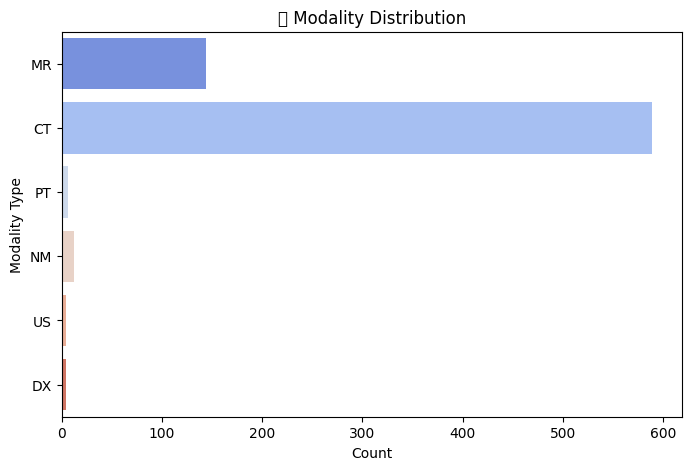

In [39]:
# 📌 Step 4: Modality Distribution
plt.figure(figsize=(8, 5))
sns.countplot(y=df['Modality'], palette='coolwarm')
plt.title("📊 Modality Distribution")
plt.xlabel("Count")
plt.ylabel("Modality Type")
plt.show()

     

C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


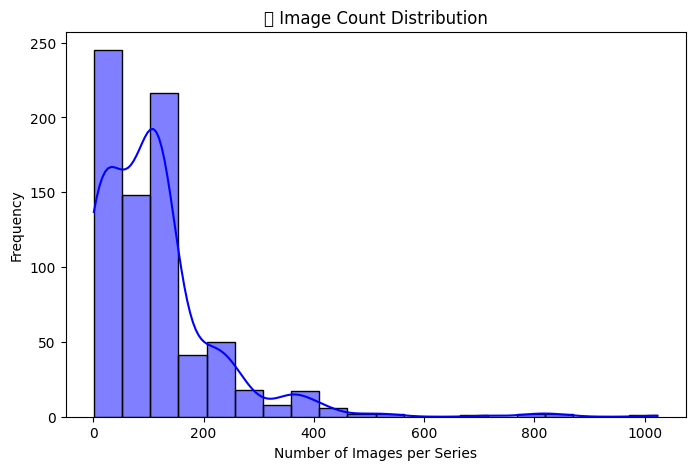

In [40]:
#📌 Image Count Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df['ImageCount'], bins=20, kde=True, color='blue')
plt.title("🖼️ Image Count Distribution")
plt.xlabel("Number of Images per Series")
plt.ylabel("Frequency")
plt.show()

C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


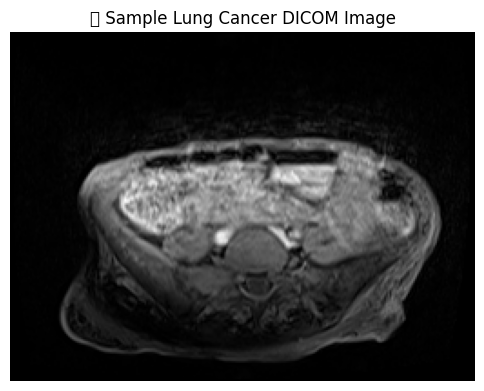

In [42]:
#📌 Visualizing a Sample DICOM Image

if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                plt.figure(figsize=(6, 6))
                plt.imshow(dicom_data.pixel_array, cmap="gray")
                plt.title("🩺 Sample Lung Cancer DICOM Image")
                plt.axis("off")
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")


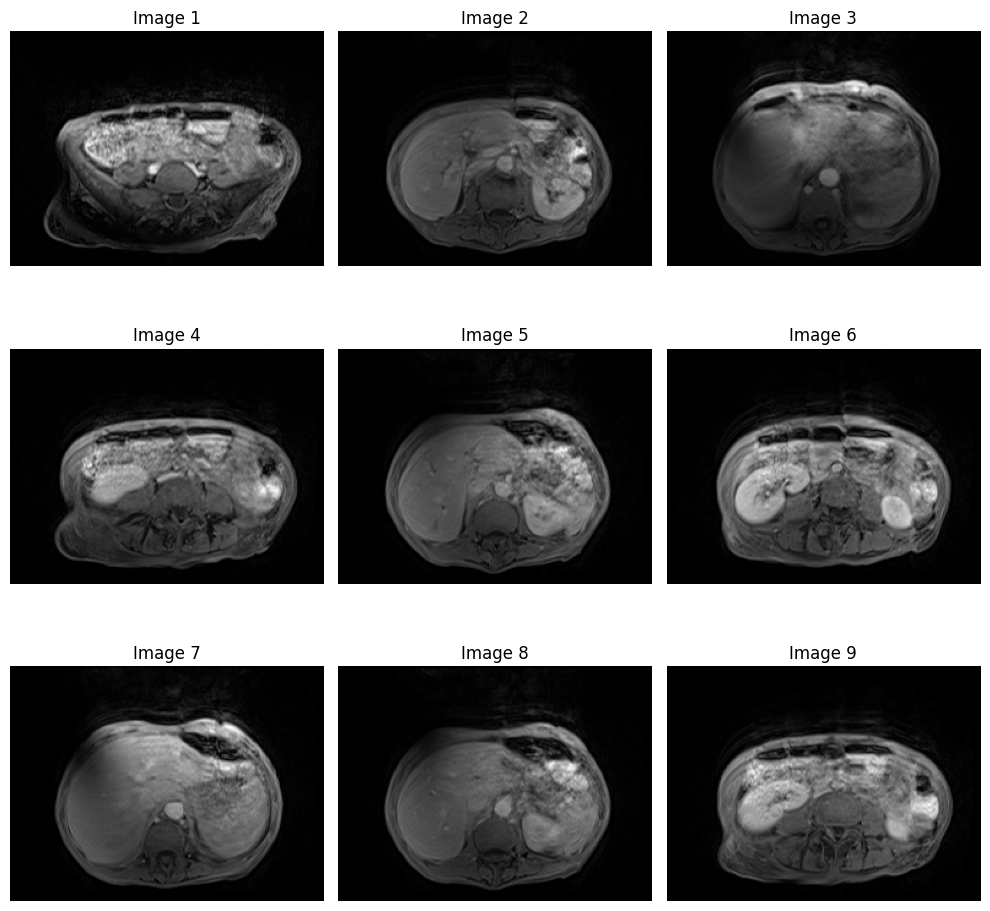

In [43]:
#📌 Display a grid of images

import numpy as np
import matplotlib.pyplot as plt

# Select first 9 images
num_images = min(9, len(dicom_files))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < num_images:
        dicom_path = os.path.join(extract_path, dicom_files[i])
        dicom_data = pydicom.dcmread(dicom_path)
        ax.imshow(dicom_data.pixel_array, cmap="gray")
        ax.set_title(f"Image {i+1}")
        ax.axis("off")

plt.tight_layout()
plt.show()
     

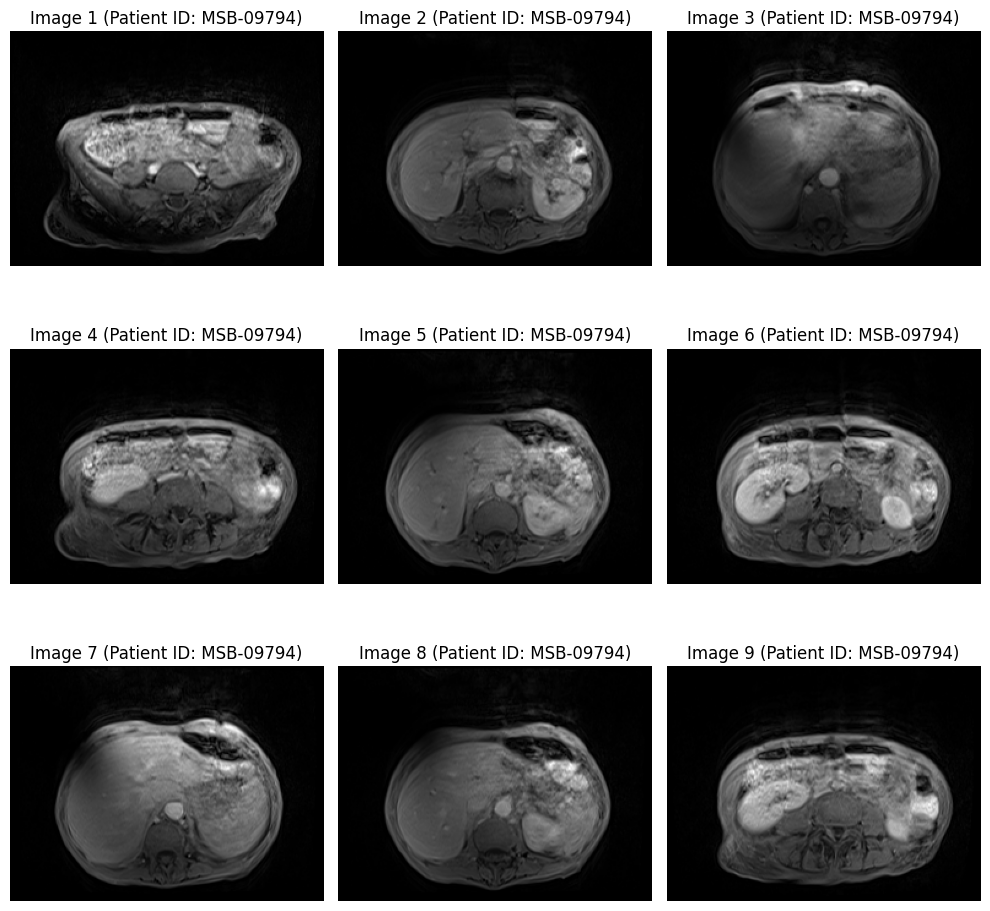

Unique Patient IDs in displayed images: {'MSB-09794'}


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pydicom

# Select first 9 images
num_images = min(9, len(dicom_files))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
patient_ids = []  # List to hold patient IDs

for i, ax in enumerate(axes.flat):
    if i < num_images:
        dicom_path = os.path.join(extract_path, dicom_files[i])
        dicom_data = pydicom.dcmread(dicom_path)
        
        # Get Patient ID from DICOM metadata
        patient_id = dicom_data.PatientID
        patient_ids.append(patient_id)
        
        ax.imshow(dicom_data.pixel_array, cmap="gray")
        ax.set_title(f"Image {i+1} (Patient ID: {patient_id})")
        ax.axis("off")

plt.tight_layout()
plt.show()

# Display unique Patient IDs
unique_patient_ids = set(patient_ids)
print(f"Unique Patient IDs in displayed images: {unique_patient_ids}")

In [47]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Constants
BASE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
COLLECTION = "CMB-LCA"

# Function to fetch data from TCIA API
def fetch_data(base_url, collection):
    # Set up parameters for the API request
    params = {
        'collection': collection
    }
    
    try:
        # Make the request to the API
        response = requests.get(base_url, params=params)
        response.raise_for_status()  # Raise an error for bad responses

        # Convert the JSON response to a DataFrame
        data = response.json()
        return pd.DataFrame(data)

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()  # Return an empty DataFrame on error

# Fetch the annotations data
annotations = fetch_data(BASE_URL, COLLECTION)

# Display the first few rows of the annotations DataFrame
print("Annotations DataFrame:")
print(annotations.head())

# Optional: Fetch the candidates data if required (replace with the appropriate API call)
# candidates = fetch_data(ANOTHER_URL, COLLECTION)

# Visualizations
if not annotations.empty:
    # 1. Correlation Matrix Heatmap
    plt.figure(figsize=(10, 6))
    correlation = annotations.corr()
    sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix for Annotations")
    plt.show()

    # 2. Distribution of Nodule Sizes (assuming there's a 'diameter_mm' column)
    if 'diameter_mm' in annotations.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(annotations['diameter_mm'], bins=30, kde=True, color='blue')
        plt.title("Distribution of Nodule Sizes (mm)")
        plt.xlabel("Diameter (mm)")
        plt.ylabel("Frequency")
        plt.axvline(annotations['diameter_mm'].mean(), color='red', linestyle='--', label='Mean Diameter')
        plt.legend()
        plt.show()

    # 3. Box Plot of Nodule Diameter by Class (if 'class' column exists)
    if 'class' in annotations.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='class', y='diameter_mm', data=annotations)
        plt.title("Box Plot of Nodule Diameter by Class")
        plt.xlabel("Class")
        plt.ylabel("Diameter (mm)")
        plt.show()

# If you need to store the DataFrame to CSV for future reference
# annotations.to_csv('annotations_data.csv', index=False)

Annotations DataFrame:
        PatientID                                   StudyInstanceUID  \
0  LIDC-IDRI-0001  1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...   
1  LIDC-IDRI-0001  1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...   
2  LIDC-IDRI-0002  1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...   
3  LIDC-IDRI-0002  1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...   
4  LIDC-IDRI-0003  1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...   

                                   SeriesInstanceUID Modality  SeriesDate  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...       DX  2000-01-01   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...       CT  2000-01-01   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...       DX  2000-01-01   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...       CT  2000-01-01   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...       CT  2000-01-01   

  BodyPartExamined    SeriesNumber AnnotationsFlag Collection  \
0            CHE

ValueError: could not convert string to float: 'LIDC-IDRI-0001'

<Figure size 1000x600 with 0 Axes>

Annotations DataFrame:
        PatientID                                   StudyInstanceUID  \
0  LIDC-IDRI-0001  1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...   
1  LIDC-IDRI-0001  1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...   
2  LIDC-IDRI-0002  1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...   
3  LIDC-IDRI-0002  1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...   
4  LIDC-IDRI-0003  1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...   

                                   SeriesInstanceUID Modality  SeriesDate  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...       DX  2000-01-01   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...       CT  2000-01-01   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...       DX  2000-01-01   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...       CT  2000-01-01   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...       CT  2000-01-01   

  BodyPartExamined    SeriesNumber AnnotationsFlag Collection  \
0            CHE

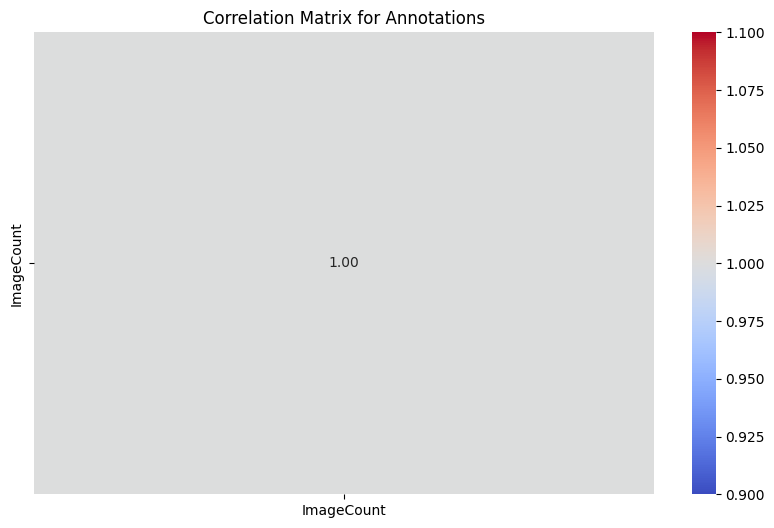

In [48]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Constants
BASE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
COLLECTION = "CMB-LCA"

# Function to fetch data from TCIA API
def fetch_data(base_url, collection):
    params = {
        'collection': collection
    }
    
    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()  # Raise an error for bad responses
        data = response.json()
        return pd.DataFrame(data)
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()  # Return an empty DataFrame on error

# Fetch the annotations data
annotations = fetch_data(BASE_URL, COLLECTION)

# Display the first few rows of the annotations DataFrame
print("Annotations DataFrame:")
print(annotations.head())

# Check if the DataFrame is not empty
if not annotations.empty:
    # 1. Correlation Matrix Heatmap (only for numeric columns)
    numeric_cols = annotations.select_dtypes(include=['number']).columns
    
    if len(numeric_cols) > 0:
        plt.figure(figsize=(10, 6))
        correlation = annotations[numeric_cols].corr()  # Only numeric columns for correlation
        sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Correlation Matrix for Annotations")
        plt.show()
    else:
        print("No numeric columns available for correlation analysis.")

    # 2. Distribution of Nodule Sizes (assuming there's a 'diameter_mm' column)
    if 'diameter_mm' in annotations.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(annotations['diameter_mm'], bins=30, kde=True, color='blue')
        plt.title("Distribution of Nodule Sizes (mm)")
        plt.xlabel("Diameter (mm)")
        plt.ylabel("Frequency")
        plt.axvline(annotations['diameter_mm'].mean(), color='red', linestyle='--', label='Mean Diameter')
        plt.legend()
        plt.show()

    # 3. Box Plot of Nodule Diameter by Class (if 'class' column exists)
    if 'class' in annotations.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='class', y='diameter_mm', data=annotations)
        plt.title("Box Plot of Nodule Diameter by Class")
        plt.xlabel("Class")
        plt.ylabel("Diameter (mm)")
        plt.show()

# Optional: Save the DataFrame to CSV for future reference
# annotations.to_csv('annotations_data.csv', index=False)

C:\Users\yosrc\AppData\Local\Temp\ipykernel_5988\3353935231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=annotations, x='Modality', palette='viridis')


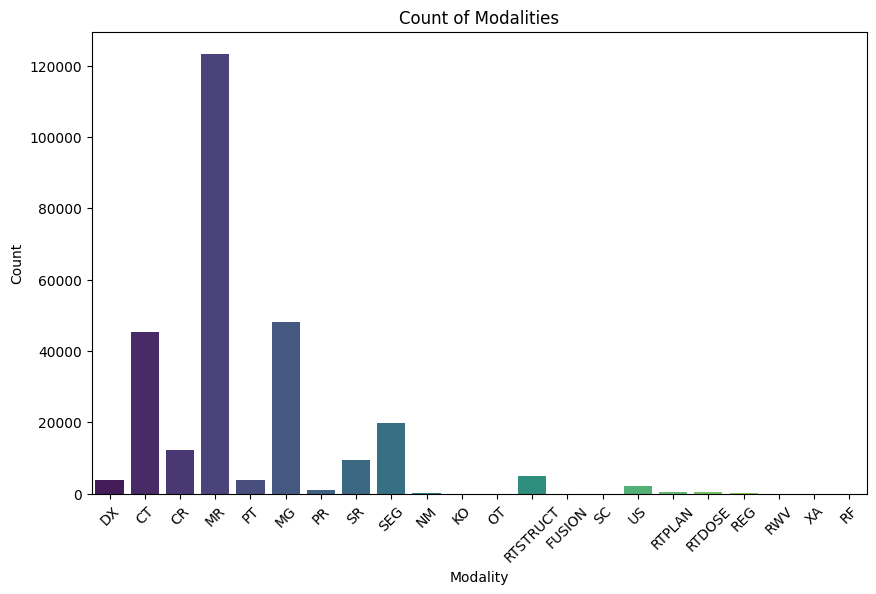

C:\Users\yosrc\AppData\Local\Temp\ipykernel_5988\3353935231.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=annotations, x='BodyPartExamined', palette='viridis')


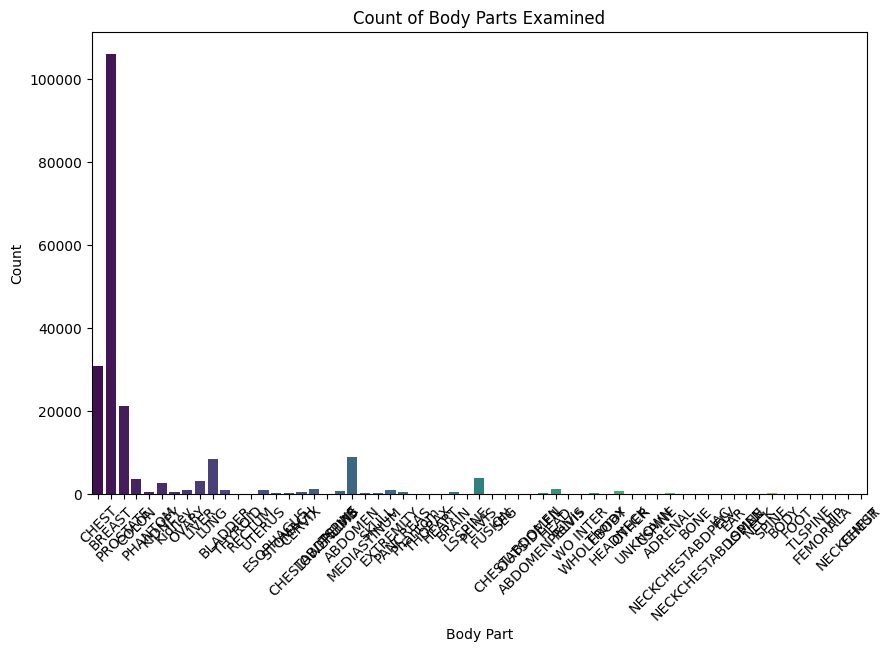

In [49]:
# Count of Modalities
plt.figure(figsize=(10, 6))
sns.countplot(data=annotations, x='Modality', palette='viridis')
plt.title("Count of Modalities")
plt.xlabel("Modality")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Count of Body Parts Examined
plt.figure(figsize=(10, 6))
sns.countplot(data=annotations, x='BodyPartExamined', palette='viridis')
plt.title("Count of Body Parts Examined")
plt.xlabel("Body Part")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\yosrc\AppData\Local\Temp\ipykernel_5988\651431053.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=patient_counts.index, y=patient_counts.values, palette='plasma')


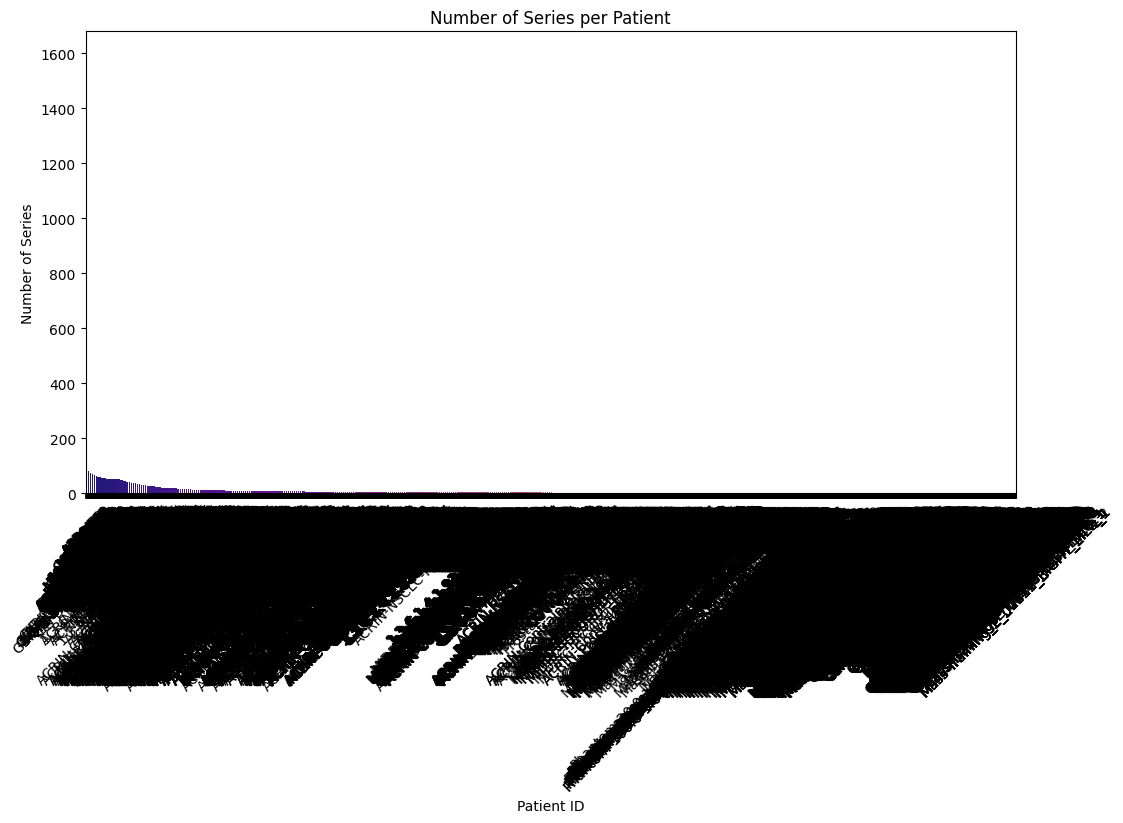

In [56]:
# Count series per Patient
patient_counts = annotations['PatientID'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=patient_counts.index, y=patient_counts.values, palette='plasma')
plt.title("Number of Series per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Number of Series")
plt.xticks(rotation=45)
plt.show()

C:\Users\yosrc\AppData\Local\Temp\ipykernel_5988\640757014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=annotations, x='Modality', y='ImageCount', palette='Set2')


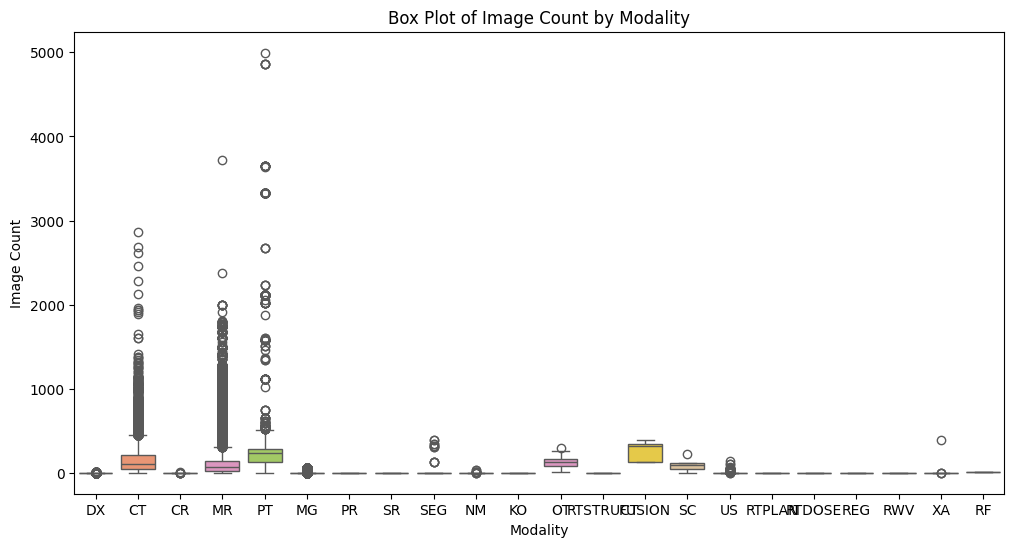

In [57]:
# Box Plot of Image Count by Modality
plt.figure(figsize=(12, 6))
sns.boxplot(data=annotations, x='Modality', y='ImageCount', palette='Set2')
plt.title("Box Plot of Image Count by Modality")
plt.xlabel("Modality")
plt.ylabel("Image Count")
plt.show()

2025-03-10 01:08:17,708:INFO:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-03-10 01:08:18,003:INFO:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


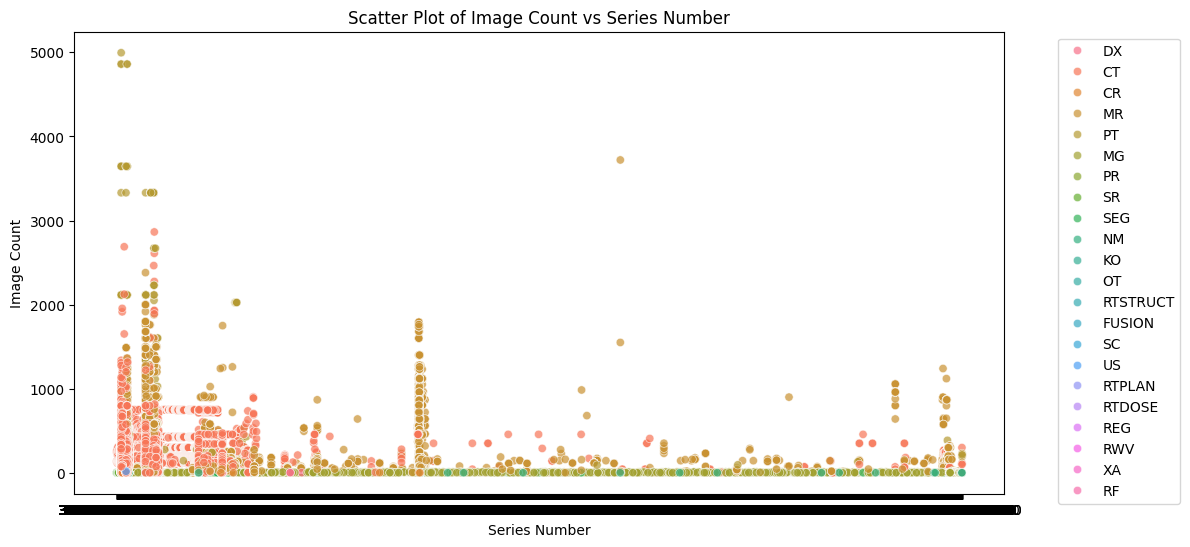

In [58]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=annotations, x='SeriesNumber', y='ImageCount', hue='Modality', alpha=0.7)
plt.title("Scatter Plot of Image Count vs Series Number")
plt.xlabel("Series Number")
plt.ylabel("Image Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

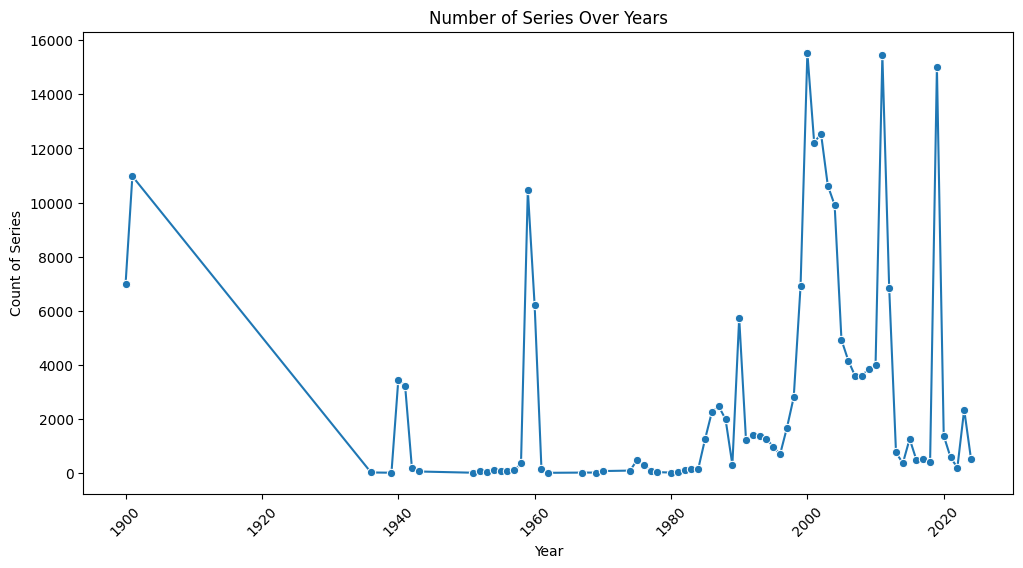

In [59]:
# Convert SeriesDate to datetime
annotations['SeriesDate'] = pd.to_datetime(annotations['SeriesDate'], errors='coerce')  # Handle invalid dates

# Extract year for aggregation
annotations['Year'] = annotations['SeriesDate'].dt.year

# Count number of series per year
series_per_year = annotations['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=series_per_year.index, y=series_per_year.values, marker='o')
plt.title("Number of Series Over Years")
plt.xlabel("Year")
plt.ylabel("Count of Series")
plt.xticks(rotation=45)
plt.show()

In [62]:
if 'diameter_mm' in annotations.columns and 'class' in annotations.columns:
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=annotations, x='class', y='diameter_mm', inner='quartile', palette='muted')
    plt.title("Violin Plot of Nodule Diameter by Class")
    plt.xlabel("Class")
    plt.ylabel("Diameter (mm)")
    plt.show()

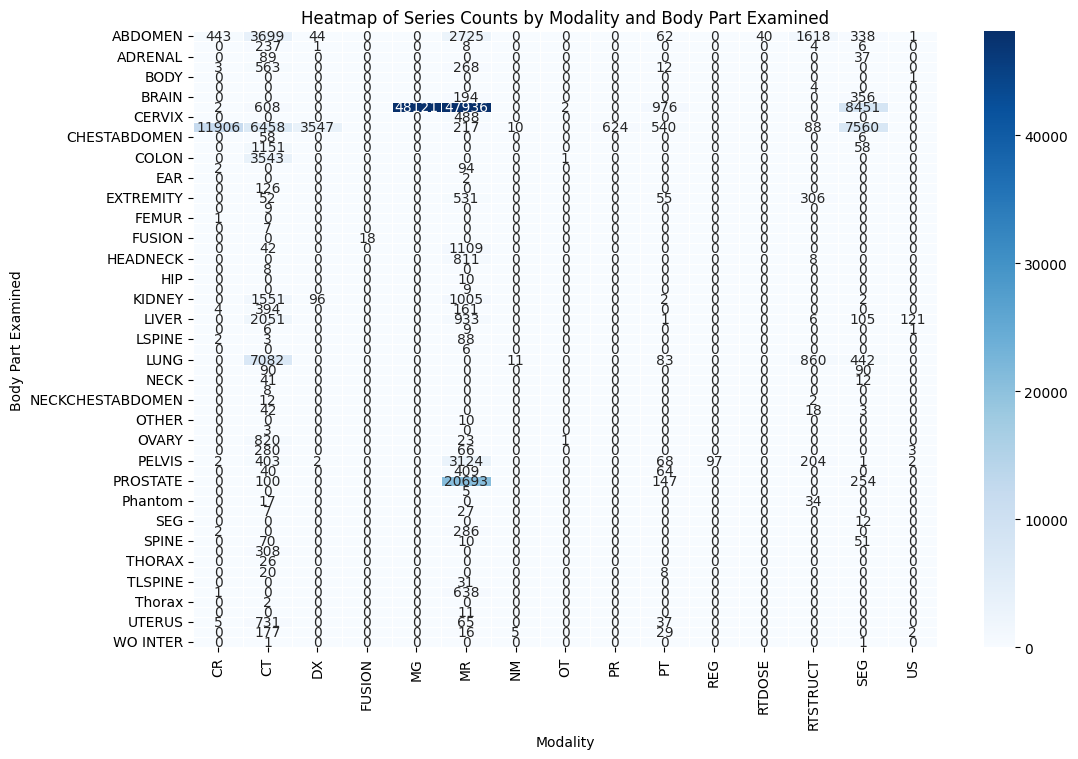

In [61]:
# Creating a pivot table for heatmap
heatmap_data = annotations.pivot_table(index='BodyPartExamined', columns='Modality', values='SeriesInstanceUID', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Blues', fmt="d", linewidths=.5)
plt.title("Heatmap of Series Counts by Modality and Body Part Examined")
plt.xlabel("Modality")
plt.ylabel("Body Part Examined")
plt.show()

In [63]:
if 'class' in annotations.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='class', y='diameter_mm', data=annotations)
    plt.title("Box Plot of Nodule Diameter by Class")
    plt.xlabel("Class")
    plt.ylabel("Diameter (mm)")
    plt.show()


In [64]:
print("Available columns:", annotations.columns)


Available columns: Index(['PatientID', 'StudyInstanceUID', 'SeriesInstanceUID', 'Modality',
       'SeriesDate', 'BodyPartExamined', 'SeriesNumber', 'AnnotationsFlag',
       'Collection', 'Manufacturer', 'ManufacturerModelName',
       'SoftwareVersions', 'Visibility', 'ImageCount', 'SeriesDescription',
       'ProtocolName', 'Year'],
      dtype='object')


In [65]:
print(annotations.head())  # Show first few rows to inspect column values


        PatientID                                   StudyInstanceUID  \
0  LIDC-IDRI-0001  1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...   
1  LIDC-IDRI-0001  1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...   
2  LIDC-IDRI-0002  1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...   
3  LIDC-IDRI-0002  1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...   
4  LIDC-IDRI-0003  1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...   

                                   SeriesInstanceUID Modality SeriesDate  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...       DX 2000-01-01   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...       CT 2000-01-01   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...       DX 2000-01-01   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...       CT 2000-01-01   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...       CT 2000-01-01   

  BodyPartExamined    SeriesNumber AnnotationsFlag Collection  \
0            CHEST  3000923.000000           

In [66]:
annotations = annotations.merge(other_dataset, on='SeriesInstanceUID', how='left')


NameError: name 'other_dataset' is not defined

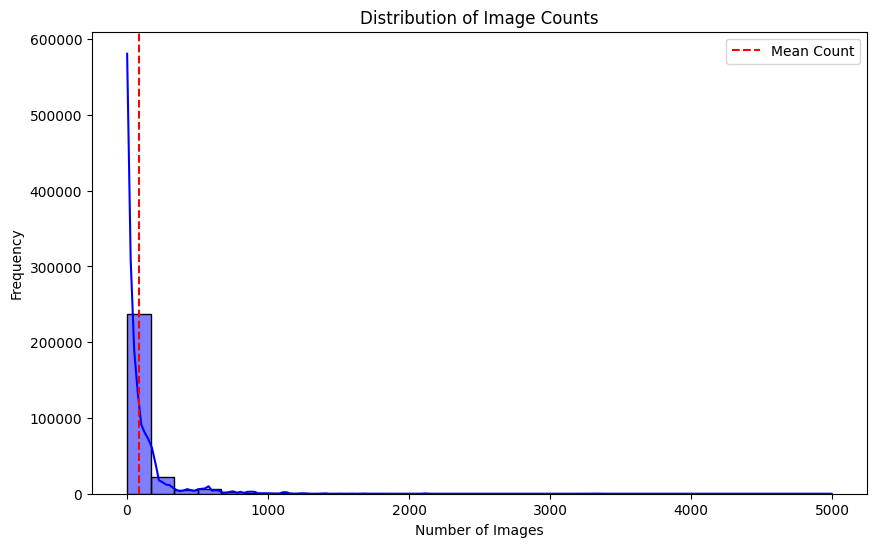

In [67]:
plt.figure(figsize=(10, 6))
sns.histplot(annotations['ImageCount'], bins=30, kde=True, color='blue')
plt.title("Distribution of Image Counts")
plt.xlabel("Number of Images")
plt.ylabel("Frequency")
plt.axvline(annotations['ImageCount'].mean(), color='red', linestyle='--', label='Mean Count')
plt.legend()
plt.show()


In [68]:
import requests
import pandas as pd

# Define API base URL
BASE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/"

# Function to fetch annotations
def fetch_annotations(collection):
    endpoint = f"{BASE_URL}getAnnotations"
    params = {'Collection': collection}
    
    try:
        response = requests.get(endpoint, params=params)
        response.raise_for_status()
        data = response.json()
        return pd.DataFrame(data) if data else None
    except requests.exceptions.RequestException as e:
        print(f"Error fetching annotations: {e}")
        return None

# Fetch annotations for your dataset (Change collection name if needed)
annotations_data = fetch_annotations("CMB-LCA")

# Display the first few rows
if annotations_data is not None:
    print(annotations_data.head())
else:
    print("No annotation data found.")


Error fetching annotations: 500 Server Error: Server Error for url: https://services.cancerimagingarchive.net/services/v4/TCIA/query/getAnnotations?Collection=CMB-LCA
No annotation data found.


In [70]:
BASE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/"
def list_collections():
    url = f"{BASE_URL}getCollectionValues"
    try:
        response = requests.get(url)
        response.raise_for_status()
        collections = response.json()
        return pd.DataFrame(collections, columns=["Collection"])
    except requests.exceptions.RequestException as e:
        print(f"Error fetching collections: {e}")
        return None

# Get list of available collections
collections_df = list_collections()
print(collections_df)


                      Collection
0                        4D-Lung
1               ACRIN-FLT-Breast
2            ACRIN-NSCLC-FDG-PET
3                         APOLLO
4                 Anti-PD-1_Lung
..                           ...
144                     CMB-BRCA
145        MIDI-B-Synthetic-Test
146  MIDI-B-Synthetic-Validation
147          MIDI-B-Curated-Test
148    MIDI-B-Curated-Validation

[149 rows x 1 columns]


In [72]:
print(collections_df[collections_df["Collection"].str.contains("Lung", case=False)])


                      Collection
0                        4D-Lung
4                 Anti-PD-1_Lung
25                  Lung Phantom
26       Lung-Fused-CT-Pathology
27                Lung-PET-CT-Dx
28              LungCT-Diagnosis
50                   QIN LUNG CT
55                 RIDER Lung CT
56             RIDER Lung PET-CT
59   SPIE-AAPM Lung CT Challenge
142           APOLLO-5-LUNG-MISC


In [74]:
lung_collections = ["4D-Lung", "LungCT-Diagnosis", "Lung-PET-CT-Dx", "SPIE-AAPM Lung CT Challenge", "QIN LUNG CT"]

for collection in lung_collections:
    print(f"Fetching annotations for: {collection}")
    annotations_data = fetch_annotations(collection)
    
    if annotations_data is not None and not annotations_data.empty:
        print(f"✅ Found annotations in: {collection}")
        print(annotations_data.head())  # Show a


Fetching annotations for: 4D-Lung
Error fetching annotations: 500 Server Error: Server Error for url: https://services.cancerimagingarchive.net/services/v4/TCIA/query/getAnnotations?Collection=4D-Lung
Fetching annotations for: LungCT-Diagnosis
Error fetching annotations: 500 Server Error: Server Error for url: https://services.cancerimagingarchive.net/services/v4/TCIA/query/getAnnotations?Collection=LungCT-Diagnosis
Fetching annotations for: Lung-PET-CT-Dx
Error fetching annotations: 500 Server Error: Server Error for url: https://services.cancerimagingarchive.net/services/v4/TCIA/query/getAnnotations?Collection=Lung-PET-CT-Dx
Fetching annotations for: SPIE-AAPM Lung CT Challenge
Error fetching annotations: 500 Server Error: Server Error for url: https://services.cancerimagingarchive.net/services/v4/TCIA/query/getAnnotations?Collection=SPIE-AAPM+Lung+CT+Challenge
Fetching annotations for: QIN LUNG CT
Error fetching annotations: 500 Server Error: Server Error for url: https://services.c

In [4]:
pip install opencv-python numpy matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import requests
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt
from io import BytesIO

# TCIA API endpoint for direct DICOM image download
DICOM_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"

# Replace with your valid SeriesInstanceUID
params = {"SeriesInstanceUID": "1.3.6.1.4.1.14519.5.2.1.4320.5030.203688968170164692143856961585"}

# Fetch the DICOM image directly
response = requests.get(DICOM_URL, params=params)
if response.status_code != 200:
    raise Exception(f"Failed to fetch DICOM image. Status: {response.status_code}")

# Read the DICOM file directly from the response
dicom_data = pydicom.dcmread(BytesIO(response.content), force=True)  # Force reading in case of missing metadata

# Convert DICOM to a NumPy array and normalize
image = dicom_data.pixel_array
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Display the original DICOM image
plt.imshow(image, cmap="gray")
plt.title("Original DICOM Image")
plt.axis("off")
plt.show()


AttributeError: Unable to decode the pixel data as the dataset's 'file_meta' has no (0002,0010) 'Transfer Syntax UID' element

In [10]:
import requests
import zipfile
import io
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# TCIA API endpoint to fetch DICOM images
DICOM_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
params = {"SeriesInstanceUID": "1.3.6.1.4.1.14519.5.2.1.4320.5030.203688968170164692143856961585"}  # Replace with a real UID

# Fetch DICOM image (ZIP format)
response = requests.get(DICOM_URL, params=params)
if response.status_code != 200:
    raise Exception(f"Failed to fetch DICOM image. Status: {response.status_code}")

# Extract the ZIP file contents
with zipfile.ZipFile(io.BytesIO(response.content), "r") as z:
    dicom_filenames = z.namelist()  # List of extracted files
    if not dicom_filenames:
        raise Exception("No DICOM files found in the ZIP archive.")
    
    dicom_file_path = dicom_filenames[0]  # Select the first DICOM file
    with z.open(dicom_file_path) as dcm_file:
        dicom_data = pydicom.dcmread(dcm_file)  # Read DICOM file

# Convert DICOM image to NumPy array for processing
image = dicom_data.pixel_array
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)  # Normalize

# Function to apply Speckle Noise
def add_speckle_noise(image):
    row, col = image.shape
    gauss = np.random.randn(row, col) * 0.2  # Adjust noise intensity
    noisy = image + image * gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Function to apply Motion Blur
def add_motion_blur(image, kernel_size=10):
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)
    kernel /= kernel_size
    return cv2.filter2D(image, -1, kernel)

# Apply noise transformations
speckle_noise = add_speckle_noise(image)
motion_blur = add_motion_blur(image)
both_noises = add_motion_blur(speckle_noise)

# Display the images
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
titles = ["Original DICOM", "Speckle Noise", "Motion Blur", "Both Noises"]
images = [image, speckle_noise, motion_blur, both_noises]

for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(titles[i])
    ax.axis("off")

plt.tight_layout()
plt.show()


InvalidDicomError: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.

In [7]:
import requests
import pandas as pd

# TCIA API Endpoint for Series information
BASE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"

# Replace with your collection name (use list_collections() to find yours)
collection_name = "LungCT-Diagnosis"  # Change this if needed

# Function to fetch Series Instance UIDs
def fetch_series_uids(collection):
    params = {"Collection": collection}
    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()
        series_list = response.json()
        return pd.DataFrame(series_list) if series_list else None
    except requests.exceptions.RequestException as e:
        print(f"Error fetching series data: {e}")
        return None

# Fetch UIDs
series_data = fetch_series_uids(collection_name)

# Display the first 10 UIDs
if series_data is not None:
    print("Available SeriesInstanceUIDs:")
    print(series_data[['SeriesInstanceUID']].head(10))  # Show first 10 UIDs
else:
    print("No series data found.")


Available SeriesInstanceUIDs:
                                   SeriesInstanceUID
0  1.3.6.1.4.1.14519.5.2.1.4320.5030.279457018741...
1  1.3.6.1.4.1.14519.5.2.1.4320.5030.966354075876...
2  1.3.6.1.4.1.14519.5.2.1.4320.5030.113686129632...
3  1.3.6.1.4.1.14519.5.2.1.4320.5030.226952804465...
4  1.3.6.1.4.1.14519.5.2.1.4320.5030.186537828665...
5  1.3.6.1.4.1.14519.5.2.1.4320.5030.357245235701...
6  1.3.6.1.4.1.14519.5.2.1.4320.5030.546493509930...
7  1.3.6.1.4.1.14519.5.2.1.4320.5030.332367356450...
8  1.3.6.1.4.1.14519.5.2.1.4320.5030.340000851536...
9  1.3.6.1.4.1.14519.5.2.1.4320.5030.325851233802...


In [8]:
random_uid = series_data["SeriesInstanceUID"].sample(1).values[0]
print(f"Randomly Selected UID: {random_uid}")


Randomly Selected UID: 1.3.6.1.4.1.14519.5.2.1.4320.5030.203688968170164692143856961585


In [13]:
if "PixelData" not in dicom_data:
    raise ValueError("This DICOM file does not contain any pixel data.")


ValueError: This DICOM file does not contain any pixel data.

In [14]:
print(dicom_data)


(4B50,0403)                                     UN: Array of 27047558 elements


C:\Users\yosrc\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydicom\hooks.py:199: UserWarning: VR lookup failed for the raw element with tag (4B50,0403) - setting VR to 'UN'
  warn_and_log(f"{msg} - setting VR to 'UN'")


In [15]:
if "TransferSyntaxUID" not in dicom_data.file_meta:
    dicom_data.file_meta.TransferSyntaxUID = "1.2.840.10008.1.2"


In [17]:
!pip install pylibjpeg pylibjpeg-libjpeg pydicom
dicom_data.decompress()
image = dicom_data.pixel_array


  Obtaining dependency information for pylibjpeg from https://files.pythonhosted.org/packages/1f/ab/8181a9ddcca65487f9f0e9054da7675ecc701fca29904c7d9d44fa8789a7/pylibjpeg-2.0.1-py3-none-any.whl.metadata
  Obtaining dependency information for pylibjpeg-libjpeg from https://files.pythonhosted.org/packages/18/3b/f2cf1a60872482804c17f357699247c3fe1f59825f7898b1c92c23dc2bde/pylibjpeg_libjpeg-2.3.0-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/744.1 kB ? eta -:--:--
   - -------------------------------------- 30.7/744.1 kB 1.4 MB/s eta 0:00:01
   ------- -------------------------------- 133.1/744.1 kB 1.6 MB/s eta 0:00:01
   --------------- ------------------------ 286.7/744.1 kB 2.2 MB/s eta 0:00:01
   ---------------------- ----------------- 409.6/744.1 kB 2.3 MB/s eta 0:00:01
   ----------------------------- ---------- 542.7/744.1 kB 2.6 MB/s eta 0:00:01
   ------------------------------------- -- 706.6/744.1 kB 2.6 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


AttributeError: Unable to decompress as the dataset has no (7FE0,0010) 'Pixel Data' element

In [18]:
import requests
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt
from io import BytesIO

# TCIA API endpoint for direct DICOM image download
DICOM_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"

# Replace with your valid SeriesInstanceUID
params = {"SeriesInstanceUID": "1.3.6.1.4.1.14519.5.2.1.4320.5030.203688968170164692143856961585"}

# Fetch the DICOM image directly
response = requests.get(DICOM_URL, params=params)
if response.status_code != 200:
    raise Exception(f"Failed to fetch DICOM image. Status: {response.status_code}")

# Read the DICOM file directly from the response
dicom_data = pydicom.dcmread(BytesIO(response.content), force=True)

# Ensure the file contains pixel data
if "PixelData" not in dicom_data:
    raise ValueError("This DICOM file does not contain any pixel data.")

# Ensure Transfer Syntax UID is present
if "TransferSyntaxUID" not in dicom_data.file_meta:
    dicom_data.file_meta.TransferSyntaxUID = "1.2.840.10008.1.2"

# Decompress if needed
try:
    dicom_data.decompress()
except:
    print("Decompression not required.")

# Convert DICOM to a NumPy array and normalize
image = dicom_data.pixel_array
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Display the original DICOM image
plt.imshow(image, cmap="gray")
plt.title("Original DICOM Image")
plt.axis("off")
plt.show()


ValueError: This DICOM file does not contain any pixel data.

In [19]:
print(dicom_data)
# Check if the file has an image
if "PixelData" not in dicom_data:
    print("This DICOM file contains metadata only (no image). Trying another one...")


(4B50,0403)                                     UN: Array of 27047558 elements
This DICOM file contains metadata only (no image). Trying another one...


In [23]:
!pip install scikit-image
import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 15
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images
                plt.figure(figsize=(12, 12))

                plt.subplot(2, 2, 1)
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(2, 2, 2)
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(2, 2, 3)
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(2, 2, 4)
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

  Obtaining dependency information for scikit-image from https://files.pythonhosted.org/packages/de/ec/b57c500ee85885df5f2188f8bb70398481393a69de44a00d6f1d055f103c/scikit_image-0.25.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for imageio!=2.35.0,>=2.33 from https://files.pythonhosted.org/packages/cb/bd/b394387b598ed84d8d0fa90611a90bee0adc2021820ad5729f7ced74a8e2/imageio-2.37.0-py3-none-any.whl.metadata
  Obtaining dependency information for tifffile>=2022.8.12 from https://files.pythonhosted.org/packages/63/70/6f363ab13f9903557a567a4471a28ee231b962e34af8e1dd8d1b0f17e64e/tifffile-2025.2.18-py3-none-any.whl.metadata
  Obtaining dependency information for lazy-loader>=0.4 from https://files.pythonhosted.org/packages/83/60/d497a310bde3f01cb805196ac61b7ad6dc5dcf8dce66634dc34364b20b4f/lazy_loader-0.4-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB 991.0 kB/s eta


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NameError: name 'df' is not defined

In [24]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scikit-image.util import random_noise  # Corrected import

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 15
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images
                plt.figure(figsize=(12, 12))

                plt.subplot(2, 2, 1)
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(2, 2, 2)
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(2, 2, 3)
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(2, 2, 4)
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

SyntaxError: invalid syntax (1904462399.py, line 10)

In [25]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise  # Corrected import

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 15
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images
                plt.figure(figsize=(12, 12))

                plt.subplot(2, 2, 1)
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(2, 2, 2)
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(2, 2, 3)
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(2, 2, 4)
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.4 MB 325.1 kB/s eta 0:02:02
   ---------------------------------------- 0.1/39.4 MB 983.0 kB/s eta 0:00:40
   ---------------------------------------- 0.3/39.4 MB 1.5 MB/s eta 0:00:27
   ---------------------------------------- 0.4/39.4 MB 1.8 MB/s eta 0:00:22
    --------------------------------------- 0.5/39.4 MB 2.0 MB/s eta 0:00:20
    --------------------------------------- 0.7/39.4 MB 2.3 MB/s eta 0:00:18
    --------------------------------------- 0.8/39.4 MB 2.3 MB/s eta 0:00:17
    --------------------------------------- 1.0/39.4 MB 2.4 MB/s eta 0:00:16


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yosrc\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NameError: name 'df' is not defined

  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl (39.4 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yosrc\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


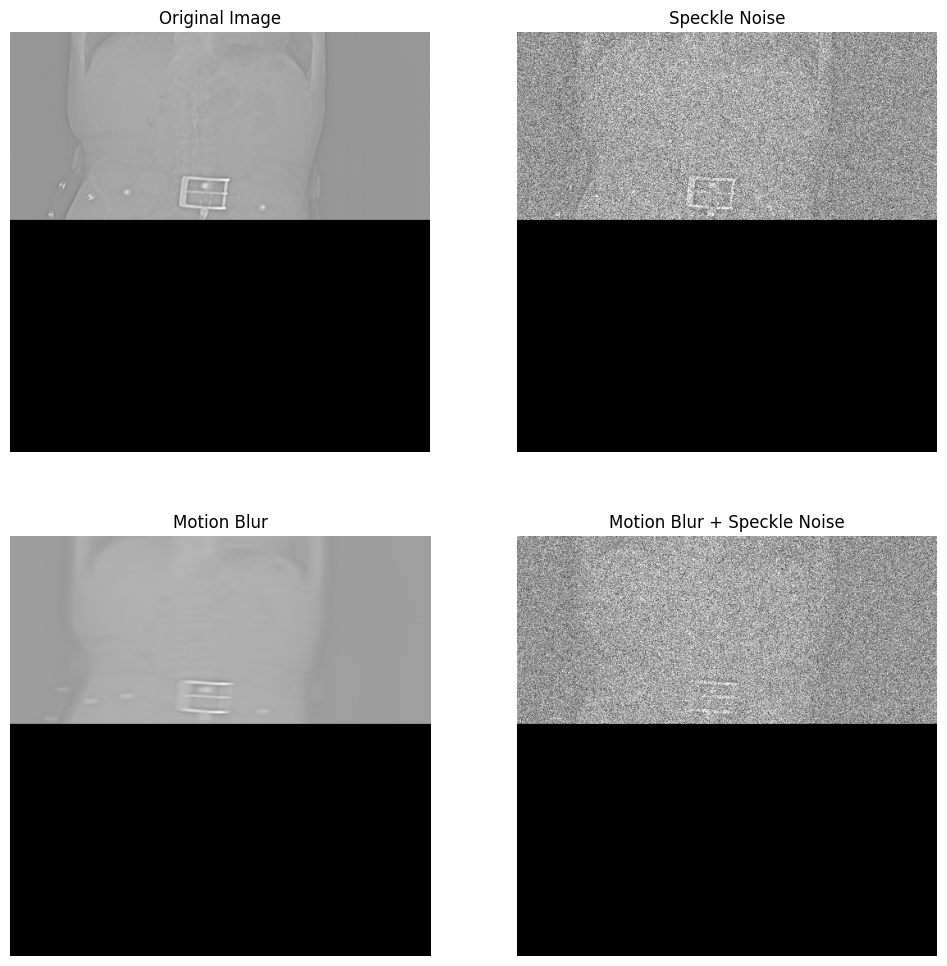

In [28]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests pandas

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Fetch metadata from TCIA API
METADATA_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": "TCGA-LUAD",  # Replace with your desired collection
    "Modality": "CT"            # Replace with your desired modality
}

response = requests.get(METADATA_URL, params=params)
if response.status_code == 200:
    metadata = response.json()
    df = pd.DataFrame(metadata)
else:
    print(f"❌ Error fetching metadata: {response.status_code}")
    df = pd.DataFrame()  # Create an empty DataFrame to avoid errors

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 15
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images
                plt.figure(figsize=(12, 12))

                plt.subplot(2, 2, 1)
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(2, 2, 2)
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(2, 2, 3)
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(2, 2, 4)
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl (39.4 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yosrc\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


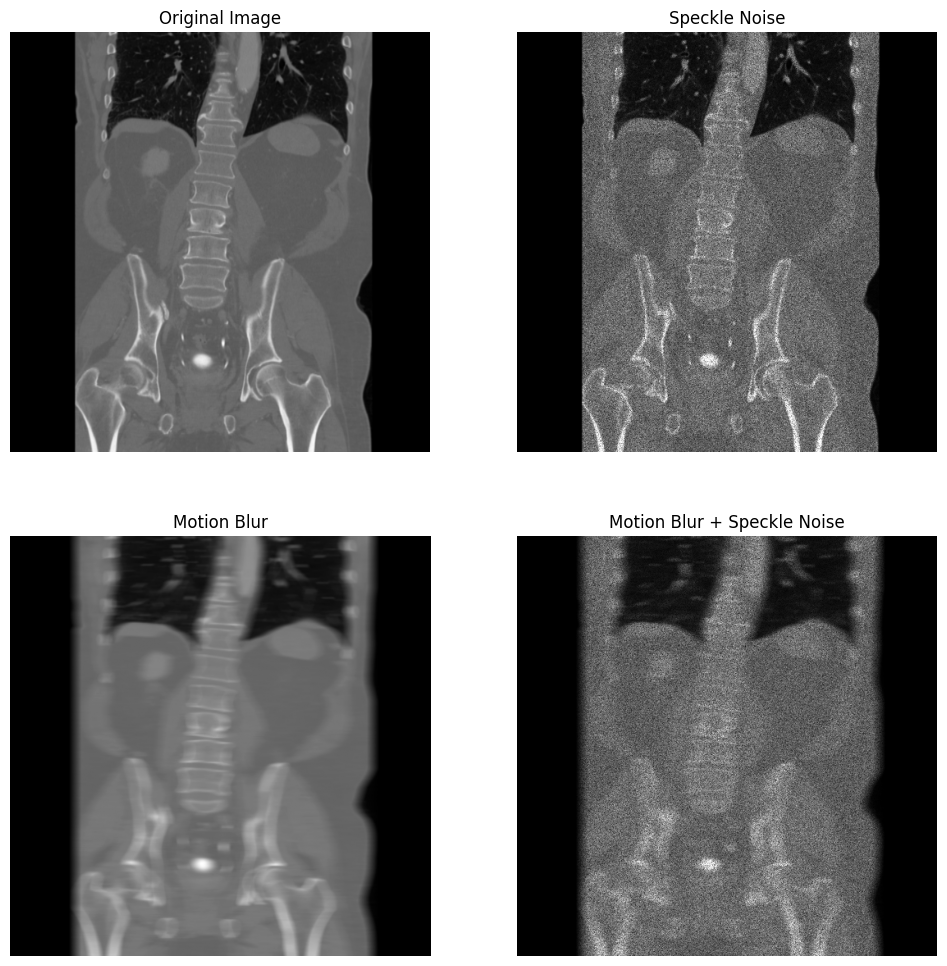

In [30]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests pandas

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Fetch metadata from TCIA API
METADATA_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": "CMB-LCA",  # Replace with your desired collection
    "Modality": "CT"            # Replace with your desired modality
}

response = requests.get(METADATA_URL, params=params)
if response.status_code == 200:
    metadata = response.json()
    df = pd.DataFrame(metadata)
else:
    print(f"❌ Error fetching metadata: {response.status_code}")
    df = pd.DataFrame()  # Create an empty DataFrame to avoid errors

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 15
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images
                plt.figure(figsize=(12, 12))

                plt.subplot(2, 2, 1)
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(2, 2, 2)
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(2, 2, 3)
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(2, 2, 4)
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl (39.4 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yosrc\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


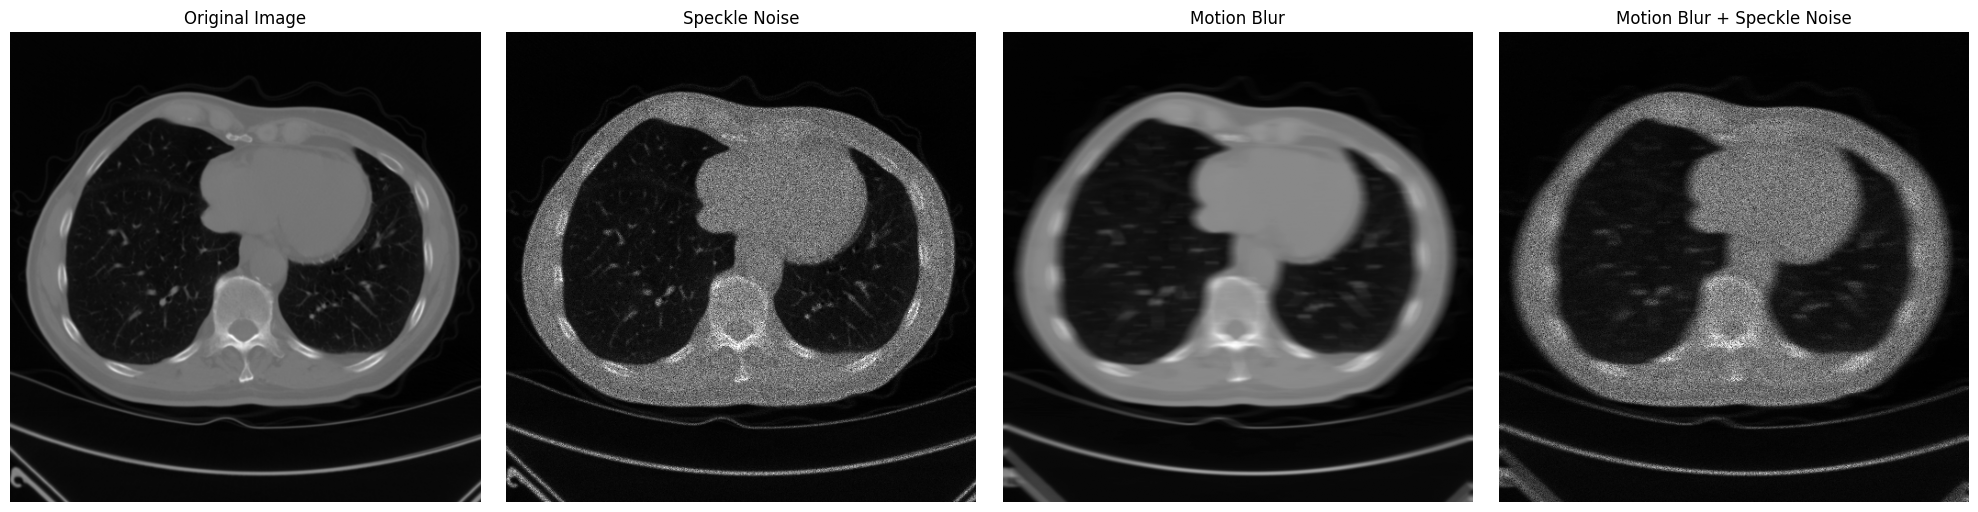

In [37]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests pandas

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Fetch metadata from TCIA API
METADATA_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": "Lung-Fused-CT-Pathology",  # Replace with your desired collection
    "Modality": "CT"            # Replace with your desired modality
}

response = requests.get(METADATA_URL, params=params)
if response.status_code == 200:
    metadata = response.json()
    df = pd.DataFrame(metadata)
else:
    print(f"❌ Error fetching metadata: {response.status_code}")
    df = pd.DataFrame()  # Create an empty DataFrame to avoid errors

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 15
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yosrc\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl (39.4 MB)


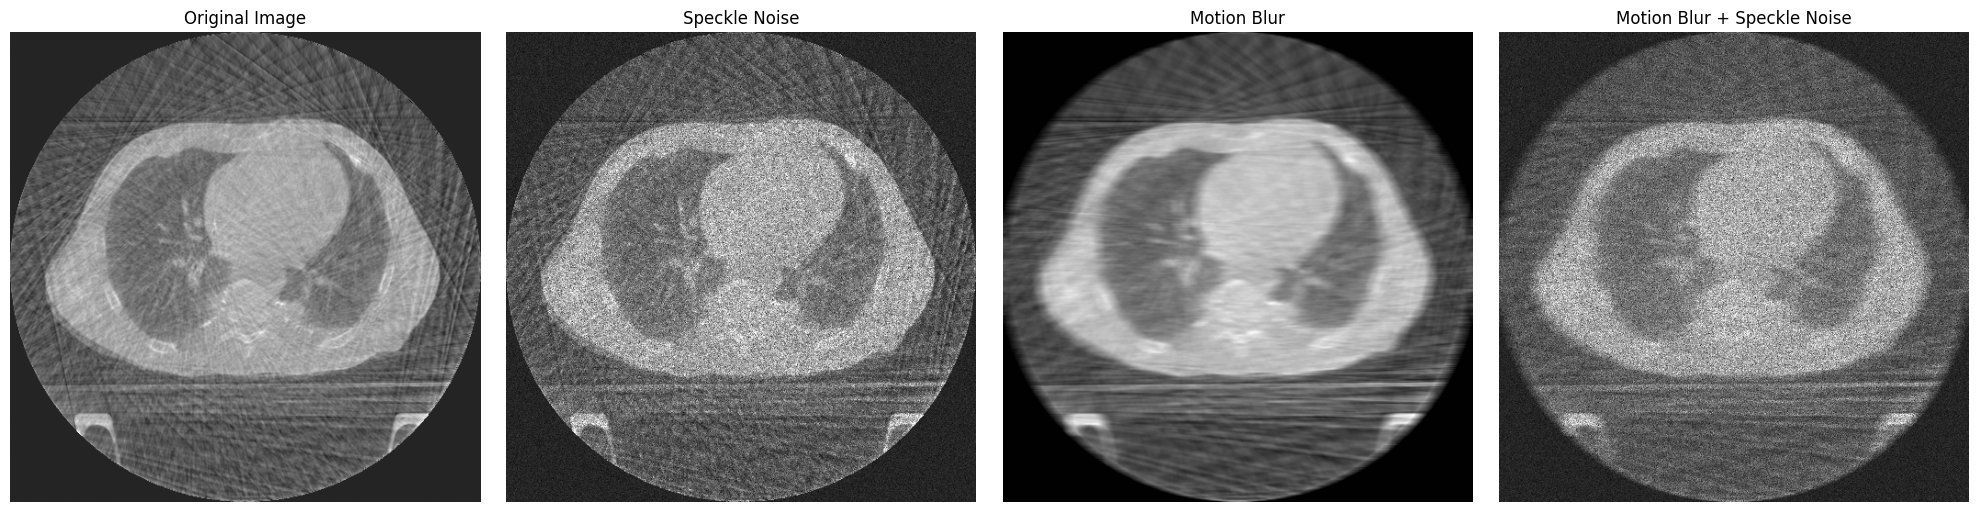

In [32]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests pandas

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Fetch metadata from TCIA API
METADATA_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": "4D-Lung",  # Replace with your desired collection
    "Modality": "CT"            # Replace with your desired modality
}

response = requests.get(METADATA_URL, params=params)
if response.status_code == 200:
    metadata = response.json()
    df = pd.DataFrame(metadata)
else:
    print(f"❌ Error fetching metadata: {response.status_code}")
    df = pd.DataFrame()  # Create an empty DataFrame to avoid errors

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 15
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yosrc\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl (39.4 MB)


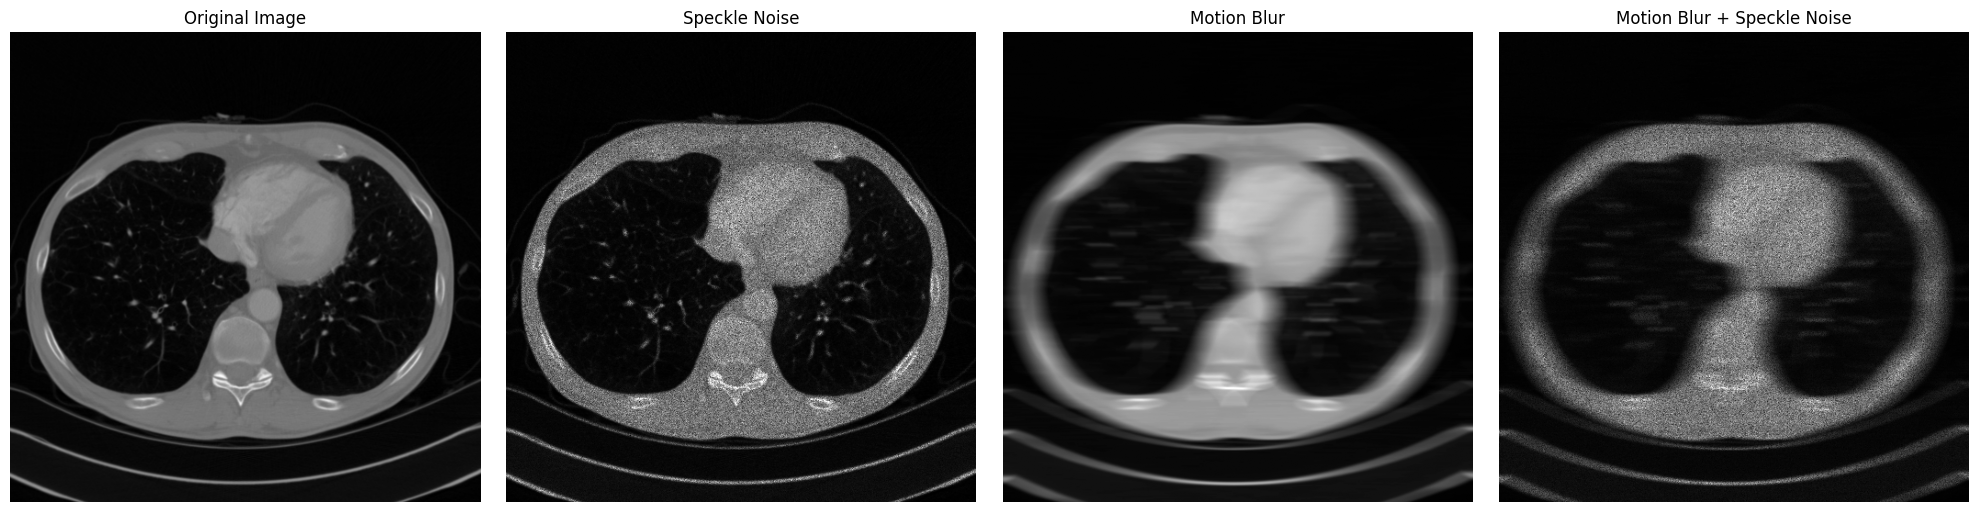

In [34]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests pandas

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Fetch metadata from TCIA API
METADATA_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": "QIN LUNG CT",  # Replace with your desired collection
    "Modality": "CT"            # Replace with your desired modality
}

response = requests.get(METADATA_URL, params=params)
if response.status_code == 200:
    metadata = response.json()
    df = pd.DataFrame(metadata)
else:
    print(f"❌ Error fetching metadata: {response.status_code}")
    df = pd.DataFrame()  # Create an empty DataFrame to avoid errors

# Fetch the DICOM image
if not df.empty:
    sample_series_uid = df.iloc[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)

    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur
                kernel_size = 30
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

In [40]:
!pip install scikit-image opencv-python-headless pydicom matplotlib requests pandas

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Define the collection and modality
COLLECTION = "APOLLO-5-LUNG-MISC"  # Replace with your desired collection
MODALITY = "PT"                    # Replace with your desired modality (e.g., MR, PT, etc.)

# Step 1: Verify the collection and modality
MODALITY_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getModalityValues"
params = {"Collection": COLLECTION}
response = requests.get(MODALITY_URL, params=params)
if response.status_code == 200:
    modalities = response.json()
    print(f"Available modalities for {COLLECTION}: {modalities}")
else:
    print(f"❌ Error fetching modalities: {response.status_code}")

# Step 2: Fetch series data
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": COLLECTION,
    "Modality": MODALITY
}
response = requests.get(SERIES_URL, params=params)
if response.status_code == 200:
    series_data = response.json()
    print(f"Number of series found: {len(series_data)}")
    if series_data:
        print("Sample series data:")
        print(series_data[0])  # Print the first series to inspect
else:
    print(f"❌ Error fetching series data: {response.status_code}")

# Step 3: Fetch and process DICOM images
if series_data:
    sample_series_uid = series_data[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)
    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]
        print(f"Number of DICOM files in the ZIP: {len(dicom_files)}")

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur (with a larger kernel for more intense blur)
                kernel_size = 30  # Increased kernel size for stronger blur
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur (Intense)")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl (39.4 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yosrc\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Available modalities for APOLLO-5-LUNG-MISC: []
Number of series found: 0


In [42]:
!pip install --user opencv-python-headless
!pip install opencv-python-headless
import requests

COLLECTION = "APOLLO-5-LUNG-MISC"
MODALITY_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getModalityValues"
params = {"Collection": COLLECTION}

response = requests.get(MODALITY_URL, params=params)
if response.status_code == 200:
    modalities = response.json()
    print(f"Available modalities for {COLLECTION}: {modalities}")
else:
    print(f"❌ Error fetching modalities: {response.status_code}")

  Obtaining dependency information for opencv-python-headless from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4f3818027203f50e6/opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-win_amd64.whl (39.4 MB)



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Available modalities for APOLLO-5-LUNG-MISC: []



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Available modalities for Lung-PET-CT-Dx: [{'Modality': 'CT'}, {'Modality': 'PT'}]
Number of series found: 133
Sample series data:
{'PatientID': 'Lung_Dx-A0166', 'StudyInstanceUID': '1.3.6.1.4.1.14519.5.2.1.6655.2359.123943627505953940638225177128', 'SeriesInstanceUID': '1.3.6.1.4.1.14519.5.2.1.6655.2359.226901752069119903728752256048', 'Modality': 'PT', 'SeriesDate': '2010-07-21', 'SeriesDescription': 'PET WB Corrected', 'SeriesNumber': '7.000000', 'Collection': 'Lung-PET-CT-Dx', 'Manufacturer': 'SIEMENS', 'ManufacturerModelName': 'Biograph 64_mCT', 'SoftwareVersions': 'VG60A', 'Visibility': '1', 'ImageCount': 171}
Number of DICOM files in the ZIP: 171


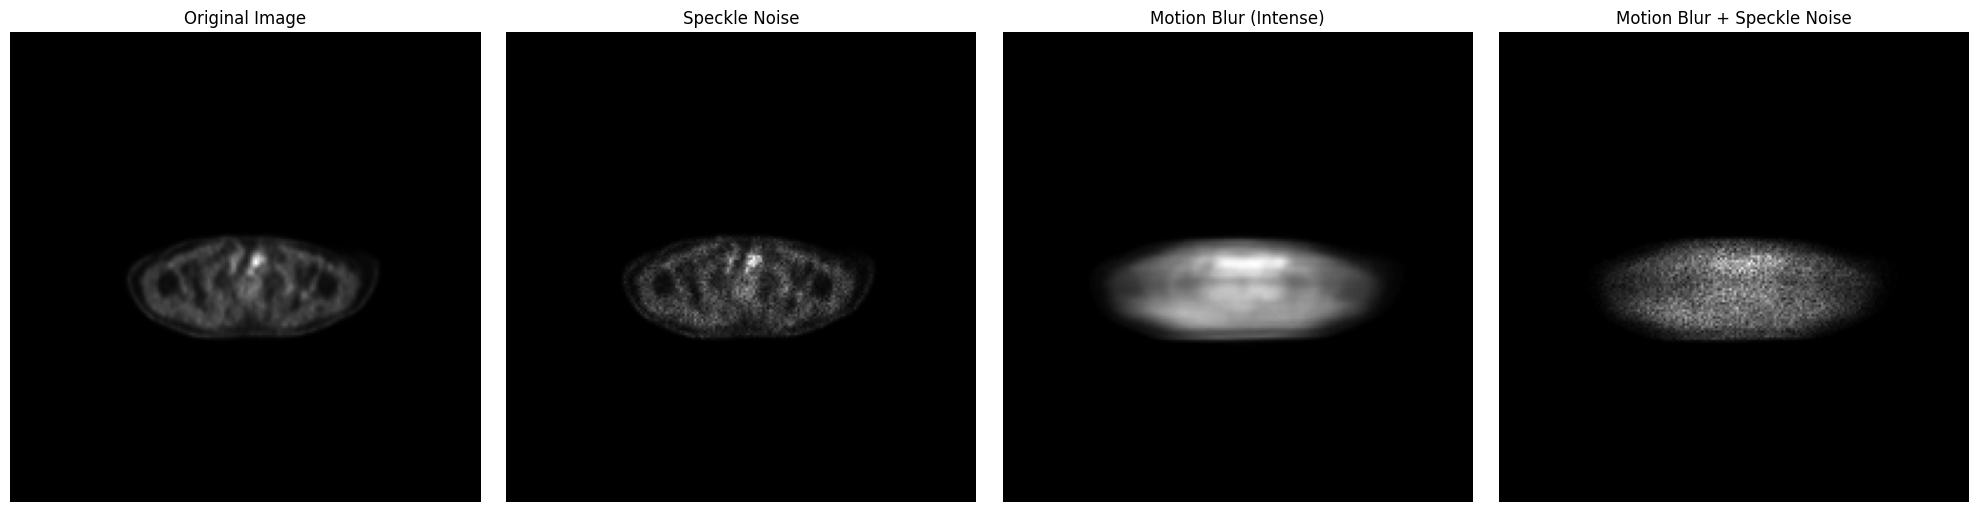

In [43]:
!pip install --user opencv-python-headless

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Define the collection and modality
COLLECTION = "Lung-PET-CT-Dx"  # Use a collection with available data
MODALITY = "PT"                # Use PET modality

# Step 1: Verify the collection and modality
MODALITY_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getModalityValues"
params = {"Collection": COLLECTION}
response = requests.get(MODALITY_URL, params=params)
if response.status_code == 200:
    modalities = response.json()
    print(f"Available modalities for {COLLECTION}: {modalities}")
else:
    print(f"❌ Error fetching modalities: {response.status_code}")

# Step 2: Fetch series data
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": COLLECTION,
    "Modality": MODALITY
}
response = requests.get(SERIES_URL, params=params)
if response.status_code == 200:
    series_data = response.json()
    print(f"Number of series found: {len(series_data)}")
    if series_data:
        print("Sample series data:")
        print(series_data[0])  # Print the first series to inspect
else:
    print(f"❌ Error fetching series data: {response.status_code}")

# Step 3: Fetch and process DICOM images
if series_data:
    sample_series_uid = series_data[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)
    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]
        print(f"Number of DICOM files in the ZIP: {len(dicom_files)}")

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur (with a larger kernel for more intense blur)
                kernel_size = 30  # Increased kernel size for stronger blur
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur (Intense)")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Available modalities for SPIE-AAPM Lung CT Challenge: [{'Modality': 'CT'}]
Number of series found: 70
Sample series data:
{'PatientID': 'CT-Training-BE006', 'StudyInstanceUID': '1.2.840.113704.1.111.1724.1168391407.1', 'SeriesInstanceUID': '1.2.840.113704.1.111.1724.1168392386.17', 'Modality': 'CT', 'ProtocolName': 'STANDARD CHEST PROTOCOL/Thorax', 'SeriesDescription': 'HIGH RES', 'BodyPartExamined': 'LUNG', 'SeriesNumber': '4.000000', 'Collection': 'SPIE-AAPM Lung CT Challenge', 'Manufacturer': 'Philips', 'ManufacturerModelName': 'Brilliance 16P', 'SoftwareVersions': '2.0.0', 'Visibility': '1', 'ImageCount': 389}
Number of DICOM files in the ZIP: 389


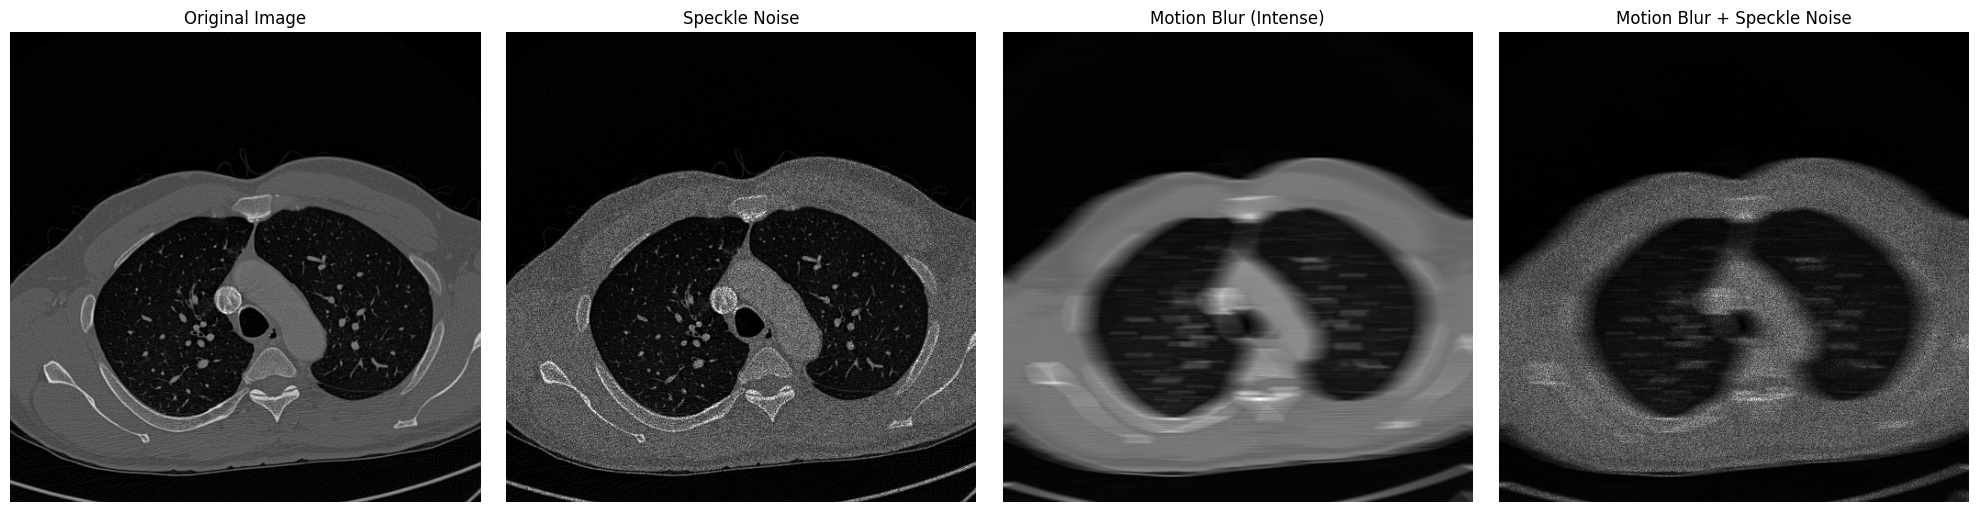

In [46]:
!pip install --user opencv-python-headless

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Define the collection and modality
COLLECTION = "SPIE-AAPM Lung CT Challenge"
MODALITY = "CT"             # Replace with your desired modality (e.g., PT, SM, etc.)

# Step 1: Verify the collection and modality
MODALITY_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getModalityValues"
params = {"Collection": COLLECTION}
response = requests.get(MODALITY_URL, params=params)
if response.status_code == 200:
    modalities = response.json()
    print(f"Available modalities for {COLLECTION}: {modalities}")
else:
    print(f"❌ Error fetching modalities: {response.status_code}")

# Step 2: Fetch series data
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": COLLECTION,
    "Modality": MODALITY
}
response = requests.get(SERIES_URL, params=params)
if response.status_code == 200:
    series_data = response.json()
    print(f"Number of series found: {len(series_data)}")
    if series_data:
        print("Sample series data:")
        print(series_data[0])  # Print the first series to inspect
else:
    print(f"❌ Error fetching series data: {response.status_code}")

# Step 3: Fetch and process DICOM images
if series_data:
    sample_series_uid = series_data[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)
    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]
        print(f"Number of DICOM files in the ZIP: {len(dicom_files)}")

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur (with a larger kernel for more intense blur)
                kernel_size = 30  # Increased kernel size for stronger blur
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur (Intense)")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Available modalities for RIDER Lung PET-CT: [{'Modality': 'PT'}, {'Modality': 'CT'}]
Number of series found: 513
Sample series data:
{'PatientID': 'RIDER-3217629044', 'StudyInstanceUID': '1.3.6.1.4.1.9328.50.17.289455334321721539058168432594454141904', 'SeriesInstanceUID': '1.3.6.1.4.1.9328.50.17.106070020843282159851467679833196223648', 'Modality': 'PT', 'SeriesDate': '2006-04-27', 'SeriesDescription': 'Offline Image', 'BodyPartExamined': 'CHEST', 'SeriesNumber': '806.000000', 'Collection': 'RIDER Lung PET-CT', 'Visibility': '1', 'ImageCount': 223}
Number of DICOM files in the ZIP: 223


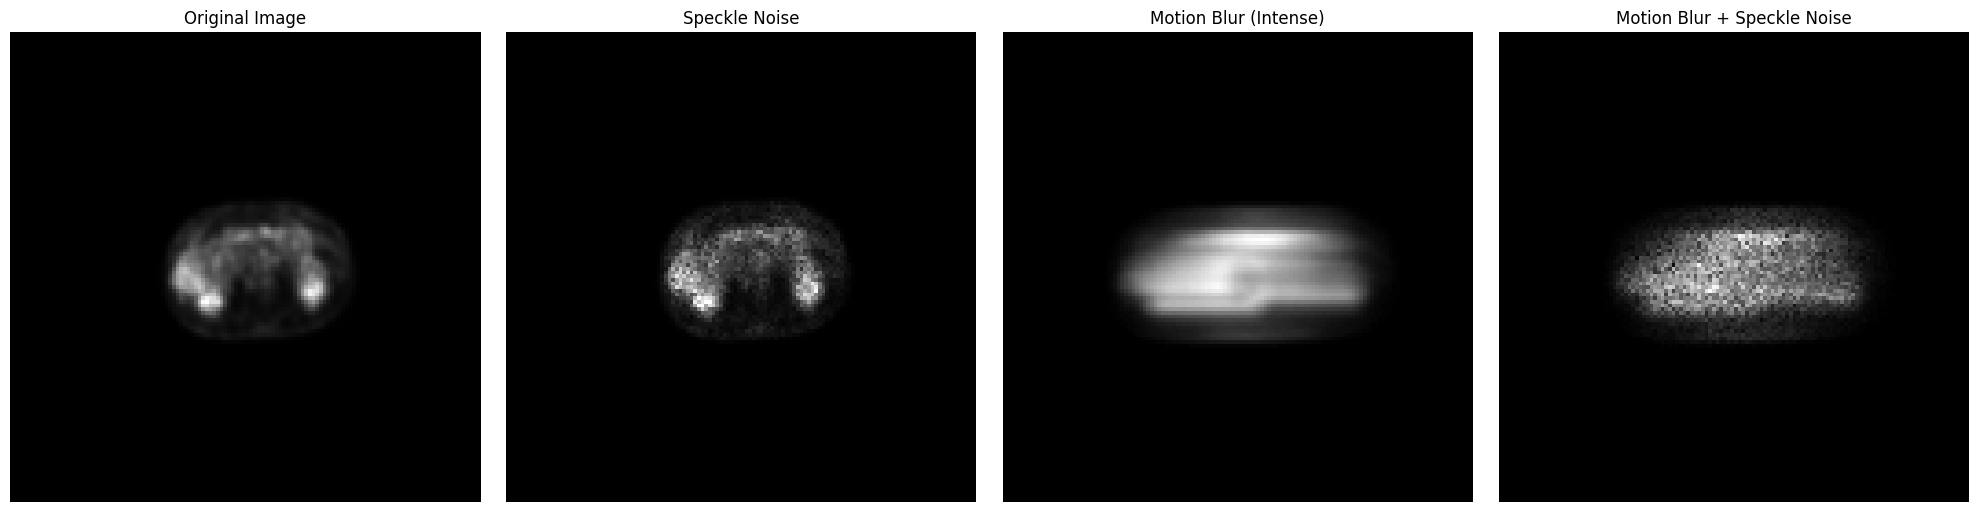

In [47]:
!pip install --user opencv-python-headless

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Define the collection and modality
COLLECTION = "RIDER Lung PET-CT"
MODALITY = "PT"              # Replace with your desired modality (e.g., PT, SM, etc.)

# Step 1: Verify the collection and modality
MODALITY_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getModalityValues"
params = {"Collection": COLLECTION}
response = requests.get(MODALITY_URL, params=params)
if response.status_code == 200:
    modalities = response.json()
    print(f"Available modalities for {COLLECTION}: {modalities}")
else:
    print(f"❌ Error fetching modalities: {response.status_code}")

# Step 2: Fetch series data
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": COLLECTION,
    "Modality": MODALITY
}
response = requests.get(SERIES_URL, params=params)
if response.status_code == 200:
    series_data = response.json()
    print(f"Number of series found: {len(series_data)}")
    if series_data:
        print("Sample series data:")
        print(series_data[0])  # Print the first series to inspect
else:
    print(f"❌ Error fetching series data: {response.status_code}")

# Step 3: Fetch and process DICOM images
if series_data:
    sample_series_uid = series_data[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)
    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]
        print(f"Number of DICOM files in the ZIP: {len(dicom_files)}")

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur (with a larger kernel for more intense blur)
                kernel_size = 30  # Increased kernel size for stronger blur
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur (Intense)")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Available modalities for RIDER Lung PET-CT: [{'Modality': 'PT'}, {'Modality': 'CT'}]
Number of series found: 815
Sample series data:
{'PatientID': 'RIDER-1002189179', 'StudyInstanceUID': '1.3.6.1.4.1.9328.50.17.74928344181377977351227961998476372019', 'SeriesInstanceUID': '1.3.6.1.4.1.9328.50.17.215396350040428026963589891044491388543', 'Modality': 'CT', 'SeriesDate': '2006-05-07', 'SeriesDescription': 'CT 2.5mm cb03', 'BodyPartExamined': 'CHEST', 'SeriesNumber': '2.000000', 'Collection': 'RIDER Lung PET-CT', 'Manufacturer': 'GE MEDICAL SYSTEMS', 'ManufacturerModelName': 'Discovery STE', 'SoftwareVersions': 'pet_vct_hp.80', 'Visibility': '1', 'ImageCount': 64}
Number of DICOM files in the ZIP: 64


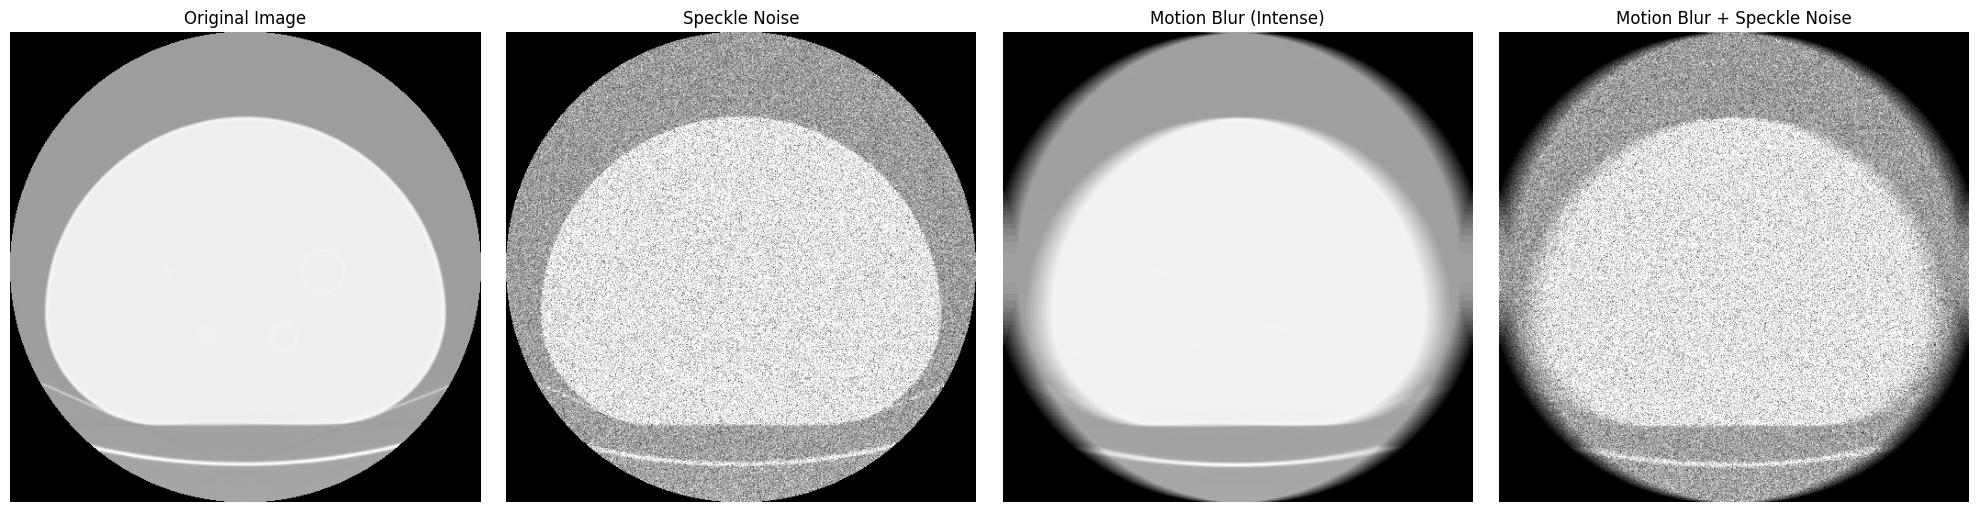

In [48]:
!pip install --user opencv-python-headless

import requests
import io
from zipfile import ZipFile
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.util import random_noise
import pandas as pd

# Define the collection and modality
COLLECTION = "RIDER Lung PET-CT"
MODALITY = "CT"              # Replace with your desired modality (e.g., PT, SM, etc.)

# Step 1: Verify the collection and modality
MODALITY_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getModalityValues"
params = {"Collection": COLLECTION}
response = requests.get(MODALITY_URL, params=params)
if response.status_code == 200:
    modalities = response.json()
    print(f"Available modalities for {COLLECTION}: {modalities}")
else:
    print(f"❌ Error fetching modalities: {response.status_code}")

# Step 2: Fetch series data
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {
    "Collection": COLLECTION,
    "Modality": MODALITY
}
response = requests.get(SERIES_URL, params=params)
if response.status_code == 200:
    series_data = response.json()
    print(f"Number of series found: {len(series_data)}")
    if series_data:
        print("Sample series data:")
        print(series_data[0])  # Print the first series to inspect
else:
    print(f"❌ Error fetching series data: {response.status_code}")

# Step 3: Fetch and process DICOM images
if series_data:
    sample_series_uid = series_data[0]["SeriesInstanceUID"]
    IMAGE_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"
    params = {"SeriesInstanceUID": sample_series_uid}

    response = requests.get(IMAGE_URL, params=params, stream=True)
    if response.status_code == 200:
        zip_file = ZipFile(io.BytesIO(response.content))
        dicom_files = [f for f in zip_file.namelist() if f.endswith(".dcm")]
        print(f"Number of DICOM files in the ZIP: {len(dicom_files)}")

        if dicom_files:
            with zip_file.open(dicom_files[0]) as dicom_file:
                dicom_data = pydicom.dcmread(io.BytesIO(dicom_file.read()))
                image = dicom_data.pixel_array

                # Normalize the image to 0-255 range for processing
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                # Apply Speckle Noise
                speckle_noise_image = random_noise(image, mode='speckle', var=0.05)
                speckle_noise_image = (255 * speckle_noise_image).astype(np.uint8)

                # Apply Motion Blur (with a larger kernel for more intense blur)
                kernel_size = 30  # Increased kernel size for stronger blur
                kernel = np.zeros((kernel_size, kernel_size))
                kernel[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
                kernel /= kernel_size
                motion_blur_image = cv2.filter2D(image, -1, kernel)

                # Apply Motion Blur and Speckle Noise
                motion_blur_speckle_image = random_noise(motion_blur_image, mode='speckle', var=0.05)
                motion_blur_speckle_image = (255 * motion_blur_speckle_image).astype(np.uint8)

                # Display the images in a single row
                plt.figure(figsize=(20, 5))  # Adjust figure size for better visibility

                plt.subplot(1, 4, 1)  # 1 row, 4 columns, 1st image
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1, 4, 2)  # 1 row, 4 columns, 2nd image
                plt.imshow(speckle_noise_image, cmap="gray")
                plt.title("Speckle Noise")
                plt.axis("off")

                plt.subplot(1, 4, 3)  # 1 row, 4 columns, 3rd image
                plt.imshow(motion_blur_image, cmap="gray")
                plt.title("Motion Blur (Intense)")
                plt.axis("off")

                plt.subplot(1, 4, 4)  # 1 row, 4 columns, 4th image
                plt.imshow(motion_blur_speckle_image, cmap="gray")
                plt.title("Motion Blur + Speckle Noise")
                plt.axis("off")

                plt.tight_layout()  # Adjust spacing between subplots
                plt.show()
        else:
            print("⚠️ No DICOM images found in the downloaded ZIP file.")
    else:
        print(f"❌ Error retrieving DICOM images: {response.status_code}")

In [1]:
import requests
import pandas as pd

# API endpoint to fetch collections
COLLECTIONS_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getCollectionValues"

# Send request to API
response = requests.get(COLLECTIONS_URL)

# Check response status
if response.status_code == 200:
    collections = pd.DataFrame(response.json())  # Convert JSON response to DataFrame
    print("Available Collections in TCIA:")
    print(collections)
else:
    print("Error fetching collections:", response.status_code)


Available Collections in TCIA:
                      Collection
0                        4D-Lung
1               ACRIN-FLT-Breast
2            ACRIN-NSCLC-FDG-PET
3                         APOLLO
4                 Anti-PD-1_Lung
..                           ...
144                     CMB-BRCA
145        MIDI-B-Synthetic-Test
146  MIDI-B-Synthetic-Validation
147          MIDI-B-Curated-Test
148    MIDI-B-Curated-Validation

[149 rows x 1 columns]


In [2]:
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"
params = {"Collection": "LungCT-Diagnosis"}  # Replace with actual dataset name

# Request series information
response = requests.get(SERIES_URL, params=params)

if response.status_code == 200:
    series_list = pd.DataFrame(response.json())
    print("Available Series in Collection:")
    print(series_list[["SeriesInstanceUID", "Modality"]])  # Print only relevant columns
else:
    print("Error fetching series:", response.status_code)


Available Series in Collection:
                                    SeriesInstanceUID Modality
0   1.3.6.1.4.1.14519.5.2.1.4320.5030.279457018741...       CT
1   1.3.6.1.4.1.14519.5.2.1.4320.5030.966354075876...       CT
2   1.3.6.1.4.1.14519.5.2.1.4320.5030.113686129632...       CT
3   1.3.6.1.4.1.14519.5.2.1.4320.5030.226952804465...       CT
4   1.3.6.1.4.1.14519.5.2.1.4320.5030.186537828665...       CT
..                                                ...      ...
56  1.3.6.1.4.1.14519.5.2.1.4320.5030.136651722353...       CT
57  1.3.6.1.4.1.14519.5.2.1.4320.5030.152764849009...       CT
58  1.3.6.1.4.1.14519.5.2.1.4320.5030.290915713367...       CT
59  1.3.6.1.4.1.14519.5.2.1.4320.5030.249790265424...       CT
60  1.3.6.1.4.1.14519.5.2.1.4320.5030.326776744705...       CT

[61 rows x 2 columns]


In [7]:
import pandas as pd
import requests

# TCIA API URL to fetch series metadata
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"

# Define the collection name
COLLECTION = "LungCT-Diagnosis"  # Change this if needed

# Fetch series metadata from TCIA
response = requests.get(SERIES_URL, params={"Collection": COLLECTION})

# Check if request was successful
if response.status_code == 200:
    series_list = pd.DataFrame(response.json())
    print("📌 Available Series in Collection:")
    print(series_list[["SeriesInstanceUID", "Modality"]].head(10))  # Show first 10 SeriesInstanceUIDs
else:
    print(f"❌ Error fetching series: {response.status_code}")


📌 Available Series in Collection:
                                   SeriesInstanceUID Modality
0  1.3.6.1.4.1.14519.5.2.1.4320.5030.279457018741...       CT
1  1.3.6.1.4.1.14519.5.2.1.4320.5030.966354075876...       CT
2  1.3.6.1.4.1.14519.5.2.1.4320.5030.113686129632...       CT
3  1.3.6.1.4.1.14519.5.2.1.4320.5030.226952804465...       CT
4  1.3.6.1.4.1.14519.5.2.1.4320.5030.186537828665...       CT
5  1.3.6.1.4.1.14519.5.2.1.4320.5030.357245235701...       CT
6  1.3.6.1.4.1.14519.5.2.1.4320.5030.546493509930...       CT
7  1.3.6.1.4.1.14519.5.2.1.4320.5030.332367356450...       CT
8  1.3.6.1.4.1.14519.5.2.1.4320.5030.340000851536...       CT
9  1.3.6.1.4.1.14519.5.2.1.4320.5030.325851233802...       CT


In [9]:
import pandas as pd
import requests

# TCIA API URL to fetch series metadata
SERIES_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getSeries"

# Define the collection name
COLLECTION = "LungCT-Diagnosis"  # Change if needed

# Fetch series metadata from TCIA
response = requests.get(SERIES_URL, params={"Collection": COLLECTION})

# Check if request was successful
if response.status_code == 200:
    series_list = pd.DataFrame(response.json())

    # Display only SeriesInstanceUIDs that contain images
    if "ImageCount" in series_list.columns:
        series_with_images = series_list[series_list["ImageCount"] > 0]
        print("\n📌 Available Series with Image Data:")
        print(series_with_images[["SeriesInstanceUID", "Modality", "ImageCount"]].head(10))
    else:
        print("❌ No ImageCount column found. This dataset may not contain medical images.")

else:
    print(f"❌ Error fetching series: {response.status_code}")



📌 Available Series with Image Data:
                                   SeriesInstanceUID Modality  ImageCount
0  1.3.6.1.4.1.14519.5.2.1.4320.5030.279457018741...       CT          73
1  1.3.6.1.4.1.14519.5.2.1.4320.5030.966354075876...       CT          68
2  1.3.6.1.4.1.14519.5.2.1.4320.5030.113686129632...       CT         130
3  1.3.6.1.4.1.14519.5.2.1.4320.5030.226952804465...       CT         109
4  1.3.6.1.4.1.14519.5.2.1.4320.5030.186537828665...       CT          74
5  1.3.6.1.4.1.14519.5.2.1.4320.5030.357245235701...       CT          62
6  1.3.6.1.4.1.14519.5.2.1.4320.5030.546493509930...       CT          69
7  1.3.6.1.4.1.14519.5.2.1.4320.5030.332367356450...       CT          66
8  1.3.6.1.4.1.14519.5.2.1.4320.5030.340000851536...       CT          83
9  1.3.6.1.4.1.14519.5.2.1.4320.5030.325851233802...       CT          71


In [11]:
import requests
import pydicom
import zipfile
import io
import numpy as np
import matplotlib.pyplot as plt
from pydicom.pixel_data_handlers.util import apply_modality_lut

# TCIA API URL to fetch DICOM images
DICOM_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getImage"

# Replace with a valid SeriesInstanceUID from your list
series_uid = "1.3.6.1.4.1.14519.5.2.1.4320.5030.279457018741..."  # Try different ones if needed

# Request the DICOM image via API
response = requests.get(DICOM_URL, params={"SeriesInstanceUID": series_uid})

# Check if request was successful
if response.status_code == 200:
    try:
        # Check if response is a ZIP file
        with zipfile.ZipFile(io.BytesIO(response.content), "r") as zip_ref:
            dicom_filenames = zip_ref.namelist()  # List all files in ZIP

            # Ensure there is at least one file in the archive
            if not dicom_filenames:
                raise Exception("No DICOM files found in the ZIP archive.")

            # Read the first DICOM file (first CT slice)
            with zip_ref.open(dicom_filenames[0]) as dcm_file:
                dicom_data = pydicom.dcmread(dcm_file, force=True)

                # Ensure the file contains pixel data
                if "PixelData" not in dicom_data:
                    raise ValueError("❌ This DICOM file does not contain any pixel data. Try another UID.")

                # Apply LUT to correctly interpret pixel values
                image = apply_modality_lut(dicom_data.pixel_array, dicom_data)

                # Normalize the pixel values for display
                image = np.clip(image, 0, 255).astype(np.uint8)

                # Display the image
                plt.imshow(image, cmap="gray")
                plt.title(f"DICOM Image - {dicom_filenames[0]}")
                plt.axis("off")
                plt.show()

                print("✅ Successfully retrieved and displayed the first DICOM slice!")

    except zipfile.BadZipFile:
        print("❌ The API response is not a valid ZIP file. Check if you're using the correct SeriesInstanceUID.")
    except Exception as e:
        print(f"❌ Error processing DICOM file: {e}")

else:
    print(f"❌ Error fetching DICOM image. HTTP Status Code: {response.status_code}")


❌ Error processing DICOM file: ❌ This DICOM file does not contain any pixel data. Try another UID.


In [15]:
MODALITY_URL = "https://services.cancerimagingarchive.net/services/v4/TCIA/query/getModalityValues"

response = requests.get(MODALITY_URL)

if response.status_code == 200:
    print("✅ API is working. Modalities Available:", response.json())
else:
    print(f"❌ API may be down. HTTP Status Code: {response.status_code}")


✅ API is working. Modalities Available: [{'Modality': 'DX'}, {'Modality': 'CT'}, {'Modality': 'CR'}, {'Modality': 'MR'}, {'Modality': 'PT'}, {'Modality': 'MG'}, {'Modality': 'PR'}, {'Modality': 'SR'}, {'Modality': 'SEG'}, {'Modality': 'NM'}, {'Modality': 'KO'}, {'Modality': 'OT'}, {'Modality': 'RTSTRUCT'}, {'Modality': 'FUSION'}, {'Modality': 'SC'}, {'Modality': 'US'}, {'Modality': 'RTPLAN'}, {'Modality': 'RTDOSE'}, {'Modality': 'REG'}, {'Modality': 'RWV'}, {'Modality': 'XA'}, {'Modality': 'RF'}]
